In [0]:
# Load dataset into dataframe
df = spark.table("waze.default.waze_dataset").toPandas()

In [0]:
df.head(10)

,ID,label,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days,device
0,0,retained,283,226,296.748273,2276,208,0,2628.845068,1985.775061,28,19,Android
1,1,retained,133,107,326.896596,1225,19,64,13715.920550,3160.472914,13,11,iPhone
2,2,retained,114,95,135.522926,2651,0,0,3059.148818,1610.735904,14,8,Android
3,3,retained,49,40,67.589221,15,322,7,913.591123,587.196542,7,3,iPhone
4,4,retained,84,68,168.247020,1562,166,5,3950.202008,1219.555924,27,18,Android
5,5,retained,113,103,279.544437,2637,0,0,901.238699,439.101397,15,11,iPhone
6,6,retained,3,2,236.725314,360,185,18,5249.172828,726.577205,28,23,iPhone
7,7,retained,39,35,176.072845,2999,0,0,7892.052468,2466.981741,22,20,iPhone
8,8,retained,57,46,183.532018,424,0,26,2651.709764,1594.342984,25,20,Android
9,9,churned,84,68,244.802115,2997,72,0,6043.460295,2341.838528,7,3,iPhone


In [0]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       14999 non-null  int64  
 1   label                    14299 non-null  object 
 2   sessions                 14999 non-null  int64  
 3   drives                   14999 non-null  int64  
 4   total_sessions           14999 non-null  float64
 5   n_days_after_onboarding  14999 non-null  int64  
 6   total_navigations_fav1   14999 non-null  int64  
 7   total_navigations_fav2   14999 non-null  int64  
 8   driven_km_drives         14999 non-null  float64
 9   duration_minutes_drives  14999 non-null  float64
 10  activity_days            14999 non-null  int64  
 11  driving_days             14999 non-null  int64  
 12  device                   14999 non-null  object 
dtypes: float64(3), int64(8), object(2)
memory usage: 1.5+ MB


1. None of the variables in the first 10 observations have missing values. Note that this does not imply the whole dataset does not have any missing values.

2. The variables label and device are of type object; total_sessions, driven_km_drives, and duration_minutes_drives are of type float64; the rest of the variables are of type int64. There are 14,999 rows and 13 columns.

In [0]:
df.isnull().sum()

ID                           0
label                      700
sessions                     0
drives                       0
total_sessions               0
n_days_after_onboarding      0
total_navigations_fav1       0
total_navigations_fav2       0
driven_km_drives             0
duration_minutes_drives      0
activity_days                0
driving_days                 0
device                       0
dtype: int64

The dataset has 700 missing values in the label column.

**Null values and summary statistics**

Compare the summary statistics of the 700 rows that are missing labels with summary statistics of the rows that are not missing any values.

Question: Is there a discernible difference between the two populations?

In [0]:
# Isolate rows with null values
null_df = df[df['label'].isnull()]
# Display summary stats of rows with null values
null_df.describe()

,ID,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days
count,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000
mean,7405.584286,80.837143,67.798571,198.483348,1709.295714,118.717143,30.371429,3935.967029,1795.123358,15.382857,12.125714
std,4306.900234,79.987440,65.271926,140.561715,1005.306562,156.308140,46.306984,2443.107121,1419.242246,8.772714,7.626373
min,77.000000,0.000000,0.000000,5.582648,16.000000,0.000000,0.000000,290.119811,66.588493,0.000000,0.000000
25%,3744.500000,23.000000,20.000000,94.056340,869.000000,4.000000,0.000000,2119.344818,779.009271,8.000000,6.000000
50%,7443.000000,56.000000,47.500000,177.255925,1650.500000,62.500000,10.000000,3421.156721,1414.966279,15.000000,12.000000
75%,11007.000000,112.250000,94.000000,266.058022,2508.750000,169.250000,43.000000,5166.097373,2443.955404,23.000000,18.000000
max,14993.000000,556.000000,445.000000,1076.879741,3498.000000,1096.000000,352.000000,15135.391280,9746.253023,31.000000,30.000000


In [0]:
# Isolate rows without null values
not_null_df = df[~df['label'].isnull()]
# Display summary stats of rows without null values
not_null_df.describe()

,ID,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days
count,14299.000000,14299.000000,14299.000000,14299.000000,14299.000000,14299.000000,14299.000000,14299.000000,14299.000000,14299.000000,14299.000000
mean,7503.573117,80.623820,67.255822,189.547409,1751.822505,121.747395,29.638296,4044.401535,1864.199794,15.544653,12.182530
std,4331.207621,80.736502,65.947295,136.189764,1008.663834,147.713428,45.350890,2504.977970,1448.005047,9.016088,7.833835
min,0.000000,0.000000,0.000000,0.220211,4.000000,0.000000,0.000000,60.441250,18.282082,0.000000,0.000000
25%,3749.500000,23.000000,20.000000,90.457733,878.500000,10.000000,0.000000,2217.319909,840.181344,8.000000,5.000000
50%,7504.000000,56.000000,48.000000,158.718571,1749.000000,71.000000,9.000000,3496.545617,1479.394387,16.000000,12.000000
75%,11257.500000,111.000000,93.000000,253.540450,2627.500000,178.000000,43.000000,5299.972162,2466.928876,23.000000,19.000000
max,14998.000000,743.000000,596.000000,1216.154633,3500.000000,1236.000000,415.000000,21183.401890,15851.727160,31.000000,30.000000


Answer: Comparing summary statistics of the observations with missing retention labels with those that aren’t missing any values reveals nothing remarkable. The means and standard deviations are fairly consistent between the two groups.

**Null values - device counts**

Next, check the two populations with respect to the device variable.

Question: How many iPhone users had null values and how many Android users had null values?

In [0]:
# Get count of null values by device
null_df['device'].value_counts()

device
iPhone     447
Android    253
Name: count, dtype: int64

Answer: > Of the 700 rows with null values, 447 were iPhone users and 253 were Android users.

Now, of the rows with null values, calculate the percentage with each device—Android and iPhone.

In [0]:
# Calculate % of iPhone nulls and Android nulls
null_df['device'].value_counts(normalize=True)

device
iPhone     0.638571
Android    0.361429
Name: proportion, dtype: float64

How does this compare to the device ratio in the full dataset?

In [0]:
# Calculate % of iPhone users and Android users in full dataset
df['device'].value_counts(normalize=True)

device
iPhone     0.644843
Android    0.355157
Name: proportion, dtype: float64

The percentage of missing values by each device is consistent with their representation in the data overall.

There is nothing to suggest a non-random cause of the missing data.

Examine the counts and percentages of users who churned vs. those who were retained. How many of each group are represented in the data?

In [0]:
# Calculate counts of churned vs. retained
print(df['label'].value_counts())
print()
print(df['label'].value_counts(normalize=True))

label
retained    11763
churned      2536
Name: count, dtype: int64

label
retained    0.822645
churned     0.177355
Name: proportion, dtype: float64


This dataset contains 82% retained users and 18% churned users.

Next, compare the medians of each variable for churned and retained users. The reason for calculating the median and not the mean is that we don’t want outliers to unduly affect the portrayal of a typical user. Notice, for example, that the maximum value in the driven_km_drives column is 21,183 km. That’s more than half the circumference of the earth!

In [0]:
# Calculate median values of all columns for churned and retained users
df.groupby('label').median(numeric_only=True)

,ID,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days
label,,,,,,,,,,,
churned,7477.5,59.0,50.0,164.339042,1321.0,84.5,11.0,3652.655666,1607.183785,8.0,6.0
retained,7509.0,56.0,47.0,157.586756,1843.0,68.0,9.0,3464.684614,1458.046141,17.0,14.0


This offers an interesting snapshot of the two groups, churned vs. retained:

Users who churned averaged ~3 more drives in the last month than retained users, but retained users used the app on over twice as many days as churned users in the same time period.

The median churned user drove ~200 more kilometers and 2.5 more hours during the last month than the median retained user.

It seems that churned users had more drives in fewer days, and their trips were farther and longer in duration. Perhaps this is suggestive of a user profile.

Calculate the median kilometers per drive in the last month for both retained and churned users. Begin by dividing the driven_km_drives column by the drives column. Then, group the results by churned/retained and calculate the median km/drive of each group.

In [0]:
# Add a column to df called `km_per_drive`
df['km_per_drive'] = df['driven_km_drives'] / df['drives']
# Group by `label`, calculate the median, and isolate for km per drive
median_km_per_drive = df.groupby('label').median(numeric_only=True)[['km_per_drive']]
median_km_per_drive

,km_per_drive
label,
churned,74.109416
retained,75.014702


The median retained user drove about one more kilometer per drive than the median churned user.
How many kilometers per driving day was this?

To calculate this statistic, repeat the steps above using driving_days instead of drives.

In [0]:
# Add a column to df called `km_per_driving_day`
df['km_per_driving_day'] = df['driven_km_drives'] / df['driving_days']
# Group by `label`, calculate the median, and isolate for km per driving day
median_km_per_driving_day = df.groupby('label').median(numeric_only=True)[['km_per_driving_day']]
median_km_per_driving_day

,km_per_driving_day
label,
churned,697.541999
retained,289.549333


Now calculate the median number of drives per driving day for each group.

In [0]:
# Add a column to df called `drives_per_driving_day`
df['drives_per_driving_day'] = df['drives'] / df['driving_days']
# Group by `label`, calculate the median, and isolate for drives per driving day
median_drives_per_driving_day = df.groupby('label').median(numeric_only=True)[['drives_per_driving_day']]
median_drives_per_driving_day

,drives_per_driving_day
label,
churned,10.0000
retained,4.0625


The median user who churned drove 698 kilometers each day they drove last month, which is ~240% the per-drive-day distance of retained users. The median churned user had a similarly
disproporionate number of drives per drive day compared to retained users.

It is clear from these figures that, regardless of whether a user churned or not, the users represented in this data are serious drivers! It would probably be safe to assume that this data does not represent typical drivers at large. Perhaps the data—and in particular the sample of churned users—contains a high proportion of long-haul truckers.

In consideration of how much these users drive, it would be worthwhile to recommend to Waze that they gather more data on these super-drivers. It’s possible that the reason for their driving so much is also the reason why the Waze app does not meet their specific set of needs, which may differ from the needs of a more typical driver, such as a commuter.

Finally, examine whether there is an imbalance in how many users churned by device type.

Begin by getting the overall counts of each device type for each group, churned and retained.

In [0]:
# For each label, calculate the number of Android users and iPhone users
df.groupby(['label', 'device']).size()

label     device 
churned   Android     891
          iPhone     1645
retained  Android    4183
          iPhone     7580
dtype: int64

Now, within each group, churned and retained, calculate what percent was Android and what percent was iPhone.

In [0]:
# For each label, calculate the percentage of Android users and iPhone users
df.groupby('label')['device'].value_counts(normalize=True)

label     device 
churned   iPhone     0.648659
          Android    0.351341
retained  iPhone     0.644393
          Android    0.355607
Name: proportion, dtype: float64

The ratio of iPhone users and Android users is consistent between the churned group and the retained group, and those ratios are both consistent with the ratio found in the overall dataset.

**Exploratory data analysis**

Questions:
    
1. Given the scenario, which data columns are most applicable?
2. Which data columns can we eliminate, knowing they won’t solve our problem scenario?
3. How would we check for missing data? And how would we handle missing data (if any)?
4. How would we check for outliers? And how would we handle outliers (if any)?

Answers:

1. Since we are interested in user churn, the label column is essential. Besides label, variables that tie to user behaviors will be the most applicable. All variables tie to user behavior except ID.
2. ID can be dropped from the analysis since we are not interested in identifying a particular user. ID does not provide meaningful information about the churn (unless ID is assigned based on user sign-up time).
3. To check for missing data, we can use df.info() and inspect the Non-Null Count column. The difference between the number of non-nulls and the number of rows in the data is the
number of missing values for the variable. If the missing data are missing completely at random (MCAR), meaning that the reason for missingness is independent of the data values themselves, we can proceed with a completecase analysis by removing the rows with missing values. Otherwise, we need to investigate the root cause of the missingness and make sure it won’t interfere with the statistical inference and modeling.

**Visualizations**

In [0]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

sessions: The number of occurrences of a user opening the app during the month

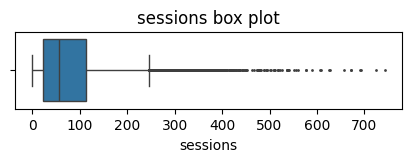

In [0]:
# Box plot
plt.figure(figsize=(5,1))
sns.boxplot(x=df['sessions'], fliersize=1)
plt.title('sessions box plot');

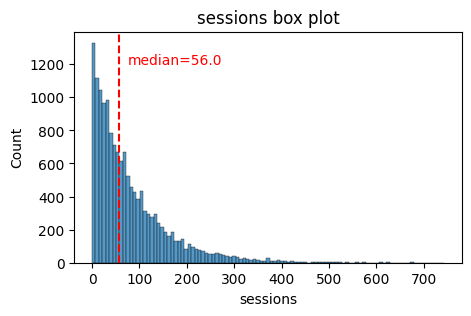

In [0]:
# Histogram
plt.figure(figsize=(5,3))
sns.histplot(x=df['sessions'])
median = df['sessions'].median()
plt.axvline(median, color='red', linestyle='--')
plt.text(75,1200, 'median=56.0', color='red')
plt.title('sessions box plot');

The sessions variable is a right-skewed distribution with half of the observations having 56 or fewer sessions. However, as indicated by the boxplot, some users have more than 700.

drives: An occurrence of driving at least 1 km during the month

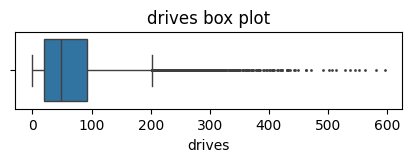

In [0]:
# Box plot
plt.figure(figsize=(5,1))
sns.boxplot(x=df['drives'], fliersize=1)
plt.title('drives box plot');

As we perform EDA, we’ll find that many tasks get repeated, such as plotting histograms of features. Remember that whenever we find ourself copy/pasting code, it’s worth considering whether a function would help make your work more efficient. Sometimes it’s not worth it. Other times, defining a function will help a lot.

The following code block defines a function that helps plot histograms with a particular style/format using this particular dataset. We don’t have to do this, but in this case it’s helpful.

In [0]:
# Helper function to plot histograms based on the
# format of the `sessions` histogram
def histogrammer(column_str, median_text=True, **kwargs): # **kwargs = any keyword arguments

                                                          # from the sns.histplot() function
    median=round(df[column_str].median(), 1)
    plt.figure(figsize=(5,3))
    ax = sns.histplot(x=df[column_str], **kwargs) # Plot the histogram
    plt.axvline(median, color='red', linestyle='--') # Plot the median line
    if median_text==True: # Add median text unless set to False
        ax.text(0.25, 0.85, f'median={median}', color='red',
            ha='left', va='top', transform=ax.transAxes)
    else:
        print('Median:', median)
    plt.title(f'{column_str} histogram');

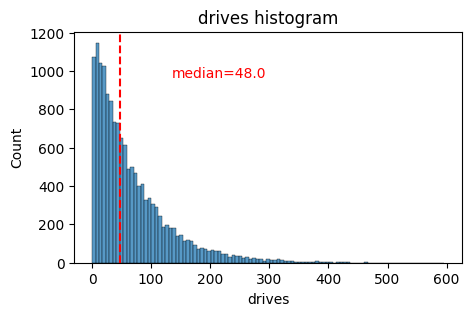

In [0]:
# Histogram
histogrammer('drives')

The drives information follows a distribution similar to the sessions variable. It is right-skewed, approximately log-normal, with a median of 48. However, some drivers had over 400 drives in the last month.

total_sessions: A model estimate of the total number of sessions since a user has onboarded

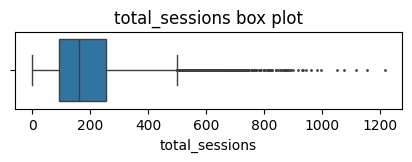

In [0]:
# Box plot
plt.figure(figsize=(5,1))
sns.boxplot(x=df['total_sessions'], fliersize=1)
plt.title('total_sessions box plot');

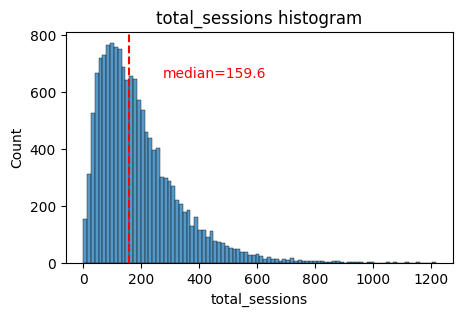

In [0]:
# Histogram
histogrammer('total_sessions')

The total_sessions is a right-skewed distribution. The median total number of sessions is 159.6. This is interesting information because, if the median number of sessions in the last month was 56 and the median total sessions was ~160, then it seems that a large proportion of a user’s (estimated) total drives might have taken place in the last month. This is something we can examine more closely later.

n_days_after_onboarding: The number of days since a user signed up for the app

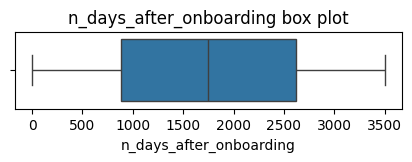

In [0]:
# Box plot
plt.figure(figsize=(5,1))
sns.boxplot(x=df['n_days_after_onboarding'], fliersize=1)
plt.title('n_days_after_onboarding box plot');

Median: 1741.0


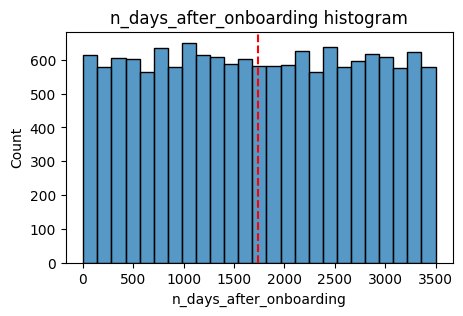

In [0]:
# Histogram
histogrammer('n_days_after_onboarding', median_text=False)

The total user tenure (i.e., number of days since onboarding) is a uniform distribution with values ranging from near-zero to ~3,500 (9.5 years).

driven_km_drives: Total kilometers driven during the month

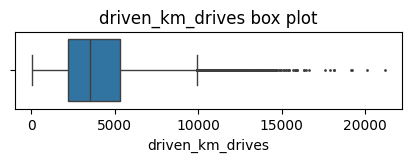

In [0]:
# Box plot
plt.figure(figsize=(5,1))
sns.boxplot(x=df['driven_km_drives'], fliersize=1)
plt.title('driven_km_drives box plot');

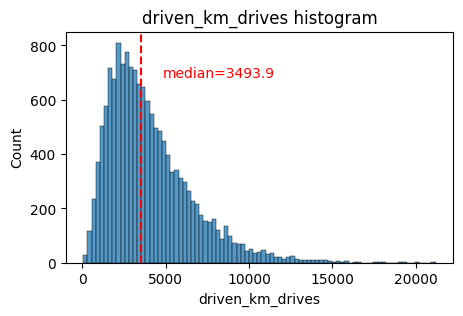

In [0]:
# Histogram
histogrammer('driven_km_drives')

The number of drives driven in the last month per user is a right-skewed distribution with half the users driving under 3,495 kilometers. As we discovered in the analysis, the users in this dataset drive a lot. The longest distance driven in the month was over half the circumferene of the earth.

duration_minutes_drives: Total duration driven in minutes during the month

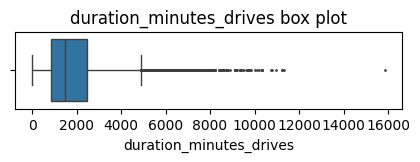

In [0]:
# Box plot
plt.figure(figsize=(5,1))
sns.boxplot(x=df['duration_minutes_drives'], fliersize=1)
plt.title('duration_minutes_drives box plot');

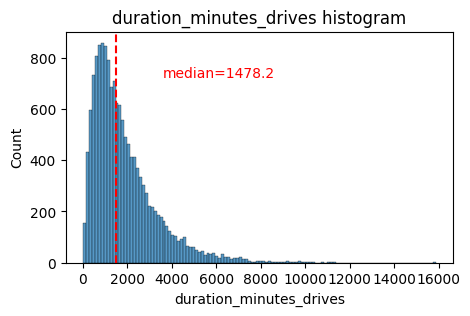

In [0]:
# Histogram
histogrammer('duration_minutes_drives')

The duration_minutes_drives variable has a heavily skewed right tail. Half of the users drove less than ~ 1,478 minutes (~25 hours), but some users clocked over 250 hours over the month.

activity_days: Number of days the user opens the app during the month

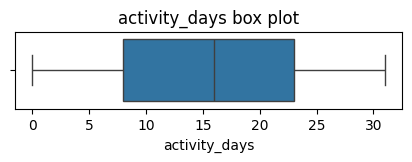

In [0]:
# Box plot
plt.figure(figsize=(5,1))
sns.boxplot(x=df['activity_days'], fliersize=1)
plt.title('activity_days box plot');

Median: 16.0


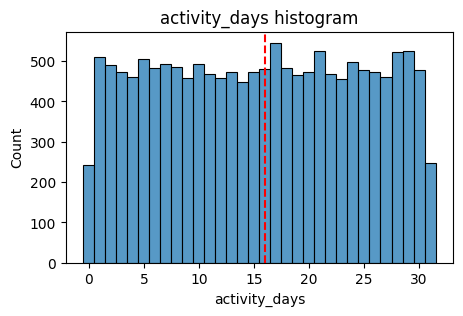

In [0]:
# Histogram
histogrammer('activity_days', median_text=False, discrete=True)

Within the last month, users opened the app a median of 16 times. The box plot reveals a centered distribution. The histogram shows a nearly uniform distribution of ~500 people opening the app on each count of days. However, there are ~250 people who didn’t open the app at all and ~250 people who opened the app every day of the month.

This distribution is noteworthy because it does not mirror the sessions distribution, which we might think would be closely correlated with activity_days.

driving_days: Number of days the user drives (at least 1 km) during the month

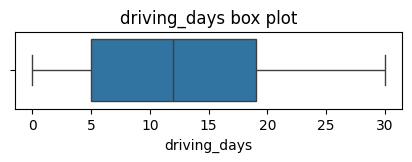

In [0]:
# Box plot
plt.figure(figsize=(5,1))
sns.boxplot(x=df['driving_days'], fliersize=1)
plt.title('driving_days box plot');

Median: 12.0


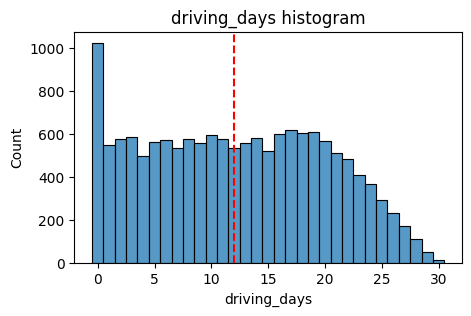

In [0]:
# Histogram
histogrammer('driving_days', median_text=False, discrete=True)

The number of days users drove each month is almost uniform, and it largely correlates with the number of days they opened the app that month, except the driving_days distribution tails off on the right.

However, there were almost twice as many users (~1,000 vs. ~550) who did not drive at all during the month. This might seem counterintuitive when considered together with the information from activity_days. That variable had ~500 users opening the app on each of most of the day counts, but there were only ~250 users who did not open the app at all during the month and ~250 users who opened the app every day. Flag this for further investigation later.

device: The type of device a user starts a session with

This is a categorical variable, so we do not plot a box plot for it. A good plot for a binary categorical variable is a pie chart.

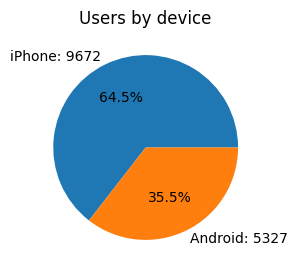

In [0]:
# Pie chart
fig = plt.figure(figsize=(3,3))
data=df['device'].value_counts()
plt.pie(data,
        labels=[f'{data.index[0]}: {data.values[0]}',
                f'{data.index[1]}: {data.values[1]}'],
        autopct='%1.1f%%'
        )
plt.title('Users by device');

There are nearly twice as many iPhone users as Android users represented in this data.

label: Binary target variable (“retained” vs “churned”) for if a user has churned anytime during the course of the month

This is also a categorical variable, and as such would not be plotted as a box plot. Plot a pie chart instead.

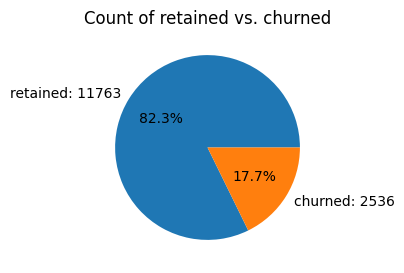

In [0]:
# Pie chart
fig = plt.figure(figsize=(3,3))
data=df['label'].value_counts()
plt.pie(data,
        labels=[f'{data.index[0]}: {data.values[0]}',
                f'{data.index[1]}: {data.values[1]}'],
        autopct='%1.1f%%'
        )
plt.title('Count of retained vs. churned');

Less than 18% of the users churned.

driving_days vs. activity_days: Because both driving_days and activity_days represent counts of days over a month and they’re also closely related, we can plot them together on a single histogram. This will help to better understand how they relate to each other without having to scroll back and forth comparing histograms in two different places.

Plot a histogram that, for each day, has a bar representing the counts of driving_days and user_days.

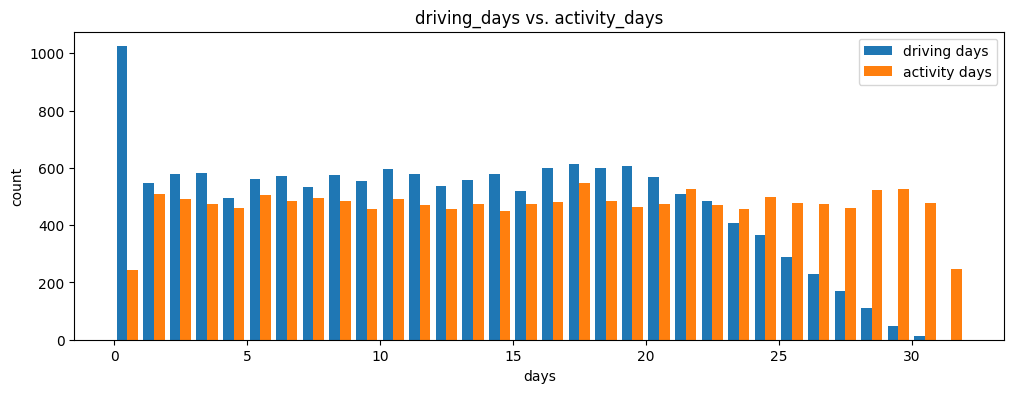

In [0]:
# Histogram
plt.figure(figsize=(12,4))
label=['driving days', 'activity days']
plt.hist([df['driving_days'], df['activity_days']],
        bins=range(0,33),
        label=label)
plt.xlabel('days')
plt.ylabel('count')
plt.legend()
plt.title('driving_days vs. activity_days');

As observed previously, this might seem counterintuitive. After all, why are there fewer people who didn’t use the app at all during the month and more people who didn’t drive at all during the month?

On the other hand, it could just be illustrative of the fact that, while these variables are related to each other, they’re not the same. People probably just open the app more than they use the app to drive—perhaps to check drive times or route information, to update settings, or even just by mistake.

Nonetheless, it might be worthwile to contact the data team at Waze to get more information about this, especially because it seems that the number of days in the month is not the same between variables.

Confirm the maximum number of days for each variable—driving_days and activity_days.

In [0]:
print(df['driving_days'].max())
print(df['activity_days'].max())

30
31


It’s true. Although it’s possible that not a single user drove all 31 days of the month, it’s highly unlikely, considering there are 15,000 people represented in the dataset.

One other way to check the validity of these variables is to plot a simple scatter plot with the x-axis representing one variable and the y-axis representing the other.

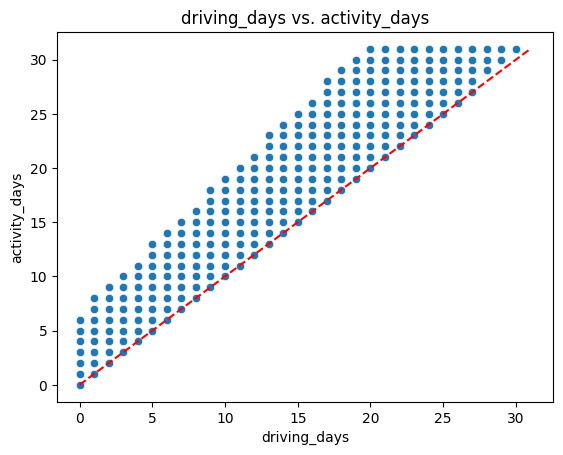

In [0]:
# Scatter plot
sns.scatterplot(data=df, x='driving_days', y='activity_days')
plt.title('driving_days vs. activity_days')
plt.plot([0,31], [0,31], color='red', linestyle='--');

Notice that there is a theoretical limit. If we use the app to drive, then by definition it must count as a day-use as well. In other words, we cannot have more drive-days than activity-days. None of the samples in this data violate this rule, which is good.

Retention by device: Plot a histogram that has four bars—one for each device-label combination—to show how many iPhone users were retained/churned and how many Android
users were retained/churned.

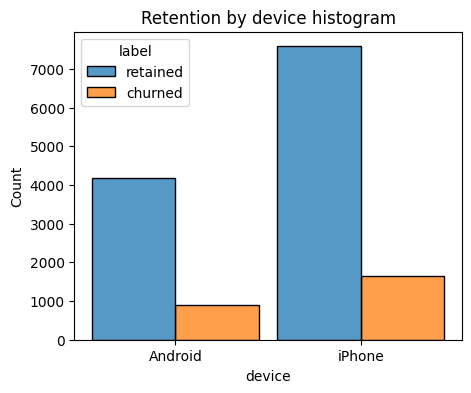

In [0]:
# Histogram
plt.figure(figsize=(5,4))
sns.histplot(data=df,
            x='device',
            hue='label',
            multiple='dodge',
            shrink=0.9
            )
plt.title('Retention by device histogram');

The proportion of churned users to retained users is consistent between device types.

Retention by kilometers driven per driving day: We discovered that the median distance driven per driving day last month for users who churned was 697.54 km, versus 289.55 km for people who did not churn. Examine this further.


    1. Create a new column in df called km_per_driving_day, which represents the mean distance driven per driving day for each user.

    2. Call the describe() method on the new column.

In [0]:
# 1. Create `km_per_driving_day` column
df['km_per_driving_day'] = df['driven_km_drives'] / df['driving_days']
# 2. Call `describe()` on the new column
df['km_per_driving_day'].describe()

/databricks/python/lib/python3.12/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


count    1.499900e+04
mean              inf
std               NaN
min      3.022063e+00
25%      1.672804e+02
50%      3.231459e+02
75%      7.579257e+02
max               inf
Name: km_per_driving_day, dtype: float64

The mean value is infinity, the standard deviation is NaN, and the max value is infinity.
This is the result of there being values of zero in the driving_days column. Pandas imputes a value of infinity in the corresponding rows of the new column because division by zero is undefined.

    1. Convert these values from infinity to zero. We can use np.inf to refer to a value of infinity.
    
    2. Call describe() on the km_per_driving_day column to verify that it worked.

In [0]:
# 1. Convert infinite values to zero
df.loc[df['km_per_driving_day']==np.inf, 'km_per_driving_day'] = 0
# 2. Confirm that it worked
df['km_per_driving_day'].describe()

count    14999.000000
mean       578.963113
std       1030.094384
min          0.000000
25%        136.238895
50%        272.889272
75%        558.686918
max      15420.234110
Name: km_per_driving_day, dtype: float64

The maximum value is 15,420 kilometers per drive day. This is physically impossible. Driving 100 km/hour for 12 hours is 1,200 km. It’s unlikely many people averaged more than this each day they drove, so, for now, disregard rows where the distance in this column is greater than 1,200 km.

Plot a histogram of the new km_per_driving_day column, disregarding those users with values greater than 1,200 km. Each bar should be the same length and have two colors, one color representing the percent of the users in that bar that churned and the other representing the percent that were retained. This can be done by setting the multiple parameter of seaborn’s histplot() function to fill.

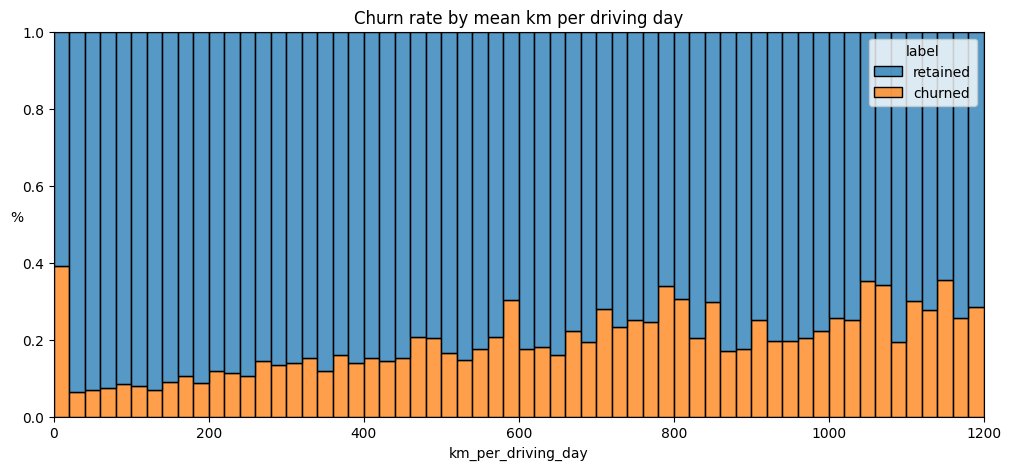

In [0]:
# Histogram
plt.figure(figsize=(12,5))
sns.histplot(data=df,
            x='km_per_driving_day',
            bins=range(0,1201,20),
            hue='label',
            multiple='fill')
plt.ylabel('%', rotation=0)
plt.title('Churn rate by mean km per driving day');

The churn rate tends to increase as the mean daily distance driven increases. It would be worth investigating further the reasons for long-distance users to discontinue using the app.

Churn rate per number of driving days: Create another histogram just like the previous one, only this time it should represent the churn rate for each number of driving days.

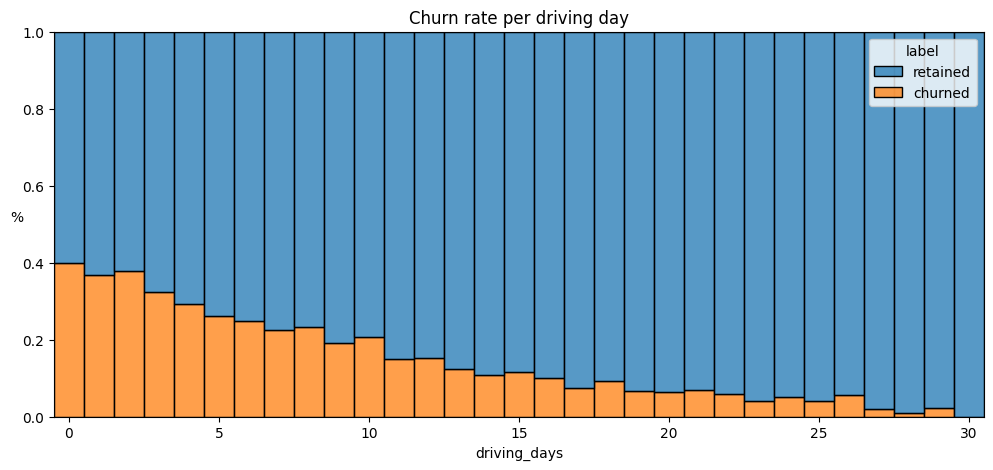

In [0]:
# Histogram
plt.figure(figsize=(12,5))
sns.histplot(data=df,
            x='driving_days',
            bins=range(1,32),
            hue='label',
            multiple='fill',
            discrete=True)
plt.ylabel('%', rotation=0)
plt.title('Churn rate per driving day');

The churn rate is highest for people who didn’t use Waze much during the last month. The more times they used the app, the less likely they were to churn. While 40% of the users who didn’t use the app at all last month churned, nobody who used the app 30 days churned.

This isn’t surprising. If people who used the app a lot churned, it would likely indicate dissatisfaction. When people who don’t use the app churn, it might be the result of dissatisfaction in the past, or it might be indicative of a lesser need for a navigational app. Maybe they moved to a city with good public transportation and don’t need to drive anymore.

Proportion of sessions that occurred in the last month: Create a new column percent_sessions_in_last_month that represents the percentage of each user’s total sessions that were logged in their last month of use.

In [0]:
df['percent_sessions_in_last_month'] = df['sessions'] / df['total_sessions']

What is the median value of the new column?

In [0]:
df['percent_sessions_in_last_month'].median()

np.float64(0.42309702992763176)

Now, create a histogram depicting the distribution of values in this new column.

Median: 0.4


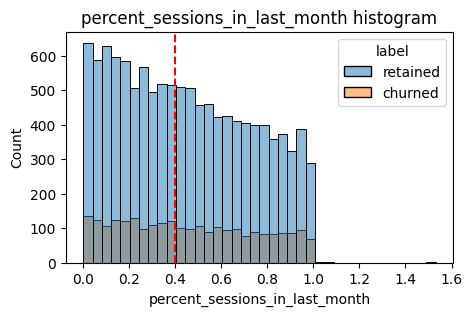

In [0]:
# Histogram
histogrammer('percent_sessions_in_last_month',
            hue=df['label'],
            multiple='layer',
            median_text=False)

Check the median value of the n_days_after_onboarding variable.

In [0]:
df['n_days_after_onboarding'].median()

np.float64(1741.0)

Half of the people in the dataset had 40% or more of their sessions in just the last month, yet the overall median time since onboarding is almost five years.

Make a histogram of n_days_after_onboarding for just the people who had 40% or more of their total sessions in the last month.

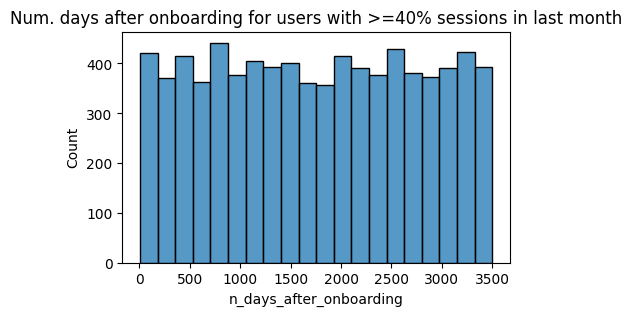

In [0]:
# Histogram
data = df.loc[df['percent_sessions_in_last_month']>=0.4]
plt.figure(figsize=(5,3))
sns.histplot(x=data['n_days_after_onboarding'])
plt.title('Num. days after onboarding for users with >=40% sessions in last month');

The number of days since onboarding for users with 40% or more of their total sessions occurring in just the last month is a uniform distribution. This is very strange. It’s worth asking Waze why so many long-time users suddenly used the app so much in the last month.

**Handling outliers**

The box plots from the previous section indicated that many of these variables have outliers. These outliers do not seem to be data entry errors; they are present because of the right-skewed distributions.

Depending on what we’ll be doing with this data, it may be useful to impute outlying data with more reasonable values. One way of performing this imputation is to set a threshold based on a percentile of the distribution.

To practice this technique, we'll write a function that calculates the 95th percentile of a given column, then imputes values > the 95th percentile with the value at the 95th percentile. such as the 95th percentile of the distribution.

In [0]:
def outlier_imputer(column_name, percentile):
    # Calculate threshold
    threshold = df[column_name].quantile(percentile)
    # Impute threshold for values > than threshold
    df.loc[df[column_name] > threshold, column_name] = threshold

    print('{:>25} | percentile: {} | threshold: {}'.format(column_name,percentile, threshold))

Next, apply that function to the following columns: * sessions * drives * total_sessions * driven_km_drives * duration_minutes_drives

In [0]:
for column in ['sessions', 'drives', 'total_sessions',
               'driven_km_drives', 'duration_minutes_drives']:
                outlier_imputer(column, 0.95)

                 sessions | percentile: 0.95 | threshold: 243.0
                   drives | percentile: 0.95 | threshold: 201.0
           total_sessions | percentile: 0.95 | threshold: 454.3632037399997
         driven_km_drives | percentile: 0.95 | threshold: 8889.7942356
  duration_minutes_drives | percentile: 0.95 | threshold: 4668.899348999998


In [0]:
df.describe()

/databricks/python/lib/python3.12/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/databricks/python/lib/python3.12/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,ID,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days,km_per_drive,km_per_driving_day,drives_per_driving_day,percent_sessions_in_last_month
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,1.499900e+04,14999.000000,1.499200e+04,14999.000000
mean,7499.000000,76.568705,64.058204,184.031320,1749.837789,121.605974,29.672512,3939.632764,1789.647426,15.537102,12.179879,inf,578.963113,inf,0.449255
std,4329.982679,67.297958,55.306924,118.600463,1008.513876,148.121544,45.394651,2216.041510,1222.705167,9.004655,7.824036,NaN,1030.094384,NaN,0.286919
min,0.000000,0.000000,0.000000,0.220211,4.000000,0.000000,0.000000,60.441250,18.282082,0.000000,0.000000,1.008775e+00,0.000000,0.000000e+00,0.000000
25%,3749.500000,23.000000,20.000000,90.661156,878.000000,9.000000,0.000000,2212.600607,835.996260,8.000000,5.000000,3.323065e+01,136.238895,1.800000e+00,0.196221
50%,7499.000000,56.000000,48.000000,159.568115,1741.000000,71.000000,9.000000,3493.858085,1478.249859,16.000000,12.000000,7.488006e+01,272.889272,4.666667e+00,0.423097
75%,11248.500000,112.000000,93.000000,254.192341,2623.500000,178.000000,43.000000,5289.861262,2464.362632,23.000000,19.000000,1.854667e+02,558.686918,1.216667e+01,0.687216
max,14998.000000,243.000000,201.000000,454.363204,3500.000000,1236.000000,415.000000,8889.794236,4668.899349,31.000000,30.000000,inf,15420.234110,inf,1.530637


Analysis revealed that the overall churn rate is ~17%, and that this rate is consistent between iPhone users and Android users.

Perhaps we feel that the more deeply we explore the data, the more questions arise. This is not uncommon! In this case, it’s worth asking the Waze data team why so many users used the app so much in just the last month.

Also, EDA has revealed that users who drive very long distances on their driving days are more likely to churn, but users who drive more often are less likely to churn. The reason for this discrepancy is an opportunity for further investigation, and it would be something else to ask the Waze data team about.

**Data exploration and hypothesis testing**

Research question:

“Do drivers who open the application using an iPhone have the same number of drives on average as drivers who use Android devices?”

In [0]:
# Import any relevant packages or libraries
import pandas as pd
from scipy import stats

Note: In the dataset, device is a categorical variable with the labels iPhone and Android.

In order to perform this analysis, we must turn each label into an integer. The following code assigns a 1 for an iPhone user and a 2 for Android. It assigns this label back to the variable device_type.

Note: Creating a new variable is ideal so that we don’t overwrite original data.

    1. Create a dictionary called map_dictionary that contains the class labels ('Android' and 'iPhone') for keys and the values we want to convert them to (2 and 1) as values.

    2. Create a new column called device_type that is a copy of the device column.

    3. Use the map() method on the device_type series. Pass map_dictionary as its argument. Reassign the result back to the device_type series. When we pass a dictionary to the Series.map() method, it will replace the data in the series where that data matches the dictionary’s keys. The values that get imputed are the values of the dictionary.

In [0]:
# 1. Create `map_dictionary`
map_dictionary = {'Android': 2, 'iPhone': 1}

# 2. Create new `device_type` column
df['device_type'] = df['device']

# 3. Map the new column to the dictionary
df['device_type'] = df['device_type'].map(map_dictionary)

df['device_type'].head()

0    2
1    1
2    2
3    1
4    2
Name: device_type, dtype: int64

We are interested in the relationship between device type and the number of drives. One approach is to look at the average number of drives for each device type. Calculate these averages.

In [0]:
df.groupby('device_type')['drives'].mean()

device_type
1    64.446340
2    63.353482
Name: drives, dtype: float64

Based on the averages shown, it appears that drivers who use an iPhone device to interact with the application have a higher number of drives on average. However, this difference might arise from random sampling, rather than being a true difference in the number of drives. To assess whether the difference is statistically significant, we can conduct a hypothesis test.

**Hypothesis testing**

The goal is to conduct a two-sample t-test. Recall the steps for conducting a hypothesis test:

    
    1. State the null hypothesis and the alternative hypothesis

    2. Choose a signficance level

    3. Find the p-value

    4. Reject or fail to reject the null hypothesis

Note: This is a t-test for two independent samples. This is the appropriate test since the two groups are independent (Android users vs. iPhone users).

Recall the difference between the null hypothesis (H0) and the alternative hypothesis (HA).

Question: What are our hypotheses for this data project?

Hypotheses:
    
H0: There is no difference in average number of drives between drivers who use iPhone devices and drivers who use Androids.

HA: There is a difference in average number of drives between drivers who use iPhone devices and drivers who use Androids.

Next, choose 5% as the significance level and proceed with a two-sample t-test.

We can use the stats.ttest_ind() function to perform the test.

**Technical note:** The default for the argument equal_var in stats.ttest_ind() is True, which assumes population variances are equal. This equal variance assumption might not hold in practice (that is, there is no strong reason to assume that the two groups have the same variance); we can relax this assumption by setting equal_var to False, and stats.ttest_ind() will perform the unequal variances t-test (known as Welch’s t-test).

    1. Isolate the drives column for iPhone users.
    2. Isolate the drives column for Android users.
    3. Perform the t-test

In [0]:
# 1. Isolate the `drives` column for iPhone users.
iPhone = df[df['device_type'] == 1]['drives']

# 2. Isolate the `drives` column for Android users.
Android = df[df['device_type'] == 2]['drives']

# 3. Perform the t-test
stats.ttest_ind(a=iPhone, b=Android, equal_var=False)

TtestResult(statistic=np.float64(1.1643714136026293), pvalue=np.float64(0.2442984426724222), df=np.float64(11148.669519764011))

Since the p-value is larger than the chosen significance level (5%), we fail to reject the null hypothesis. We conclude that there is not a statistically significant difference in the average number of drives between drivers who use iPhones and drivers who use Androids.

Regression modeling

We will build a binomial logistic regression model. Logistic regression helps estimate the probability of an outcome. This is a useful skill because it allows us to consider more than one variable against the variable we’re measuring against. This opens the door for much more thorough and flexible analysis to be completed.

The goal is to build a binomial logistic regression model and evaluate the model’s performance.

This has three parts:
    
Part 1: EDA & Checking Model Assumptions * What are some purposes of EDA before constructing a binomial logistic regression model?

Part 2: Model Building and Evaluation * What resources do we find ourself using as we complete this stage?

Part 3: Interpreting Model Results

  • What key insights emerged from our model(s)?
  
  • What business recommendations do we propose based on the models built?

In [0]:
# Packages for Logistic Regression & Confusion Matrix
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, precision_score, \
recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

Analyze and discover data, looking for correlations, missing data, potential outliers, and/or duplicates.

In [0]:
print(df.shape)
df.info()

(14999, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   ID                              14999 non-null  int64  
 1   label                           14299 non-null  object 
 2   sessions                        14999 non-null  int64  
 3   drives                          14999 non-null  int64  
 4   total_sessions                  14999 non-null  float64
 5   n_days_after_onboarding         14999 non-null  int64  
 6   total_navigations_fav1          14999 non-null  int64  
 7   total_navigations_fav2          14999 non-null  int64  
 8   driven_km_drives                14999 non-null  float64
 9   duration_minutes_drives         14999 non-null  float64
 10  activity_days                   14999 non-null  int64  
 11  driving_days                    14999 non-null  int64  
 12  device              

Question: Are there any missing values in your data?

Yes, the label column is missing 700 values.

In [0]:
df.head()

,ID,label,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days,device,km_per_drive,km_per_driving_day,drives_per_driving_day,percent_sessions_in_last_month,device_type
0,0,retained,243,201,296.748273,2276,208,0,2628.845068,1985.775061,28,19,Android,11.632058,138.360267,11.894737,0.953670,2
1,1,retained,133,107,326.896596,1225,19,64,8889.794236,3160.472914,13,11,iPhone,128.186173,1246.901868,9.727273,0.406856,1
2,2,retained,114,95,135.522926,2651,0,0,3059.148818,1610.735904,14,8,Android,32.201567,382.393602,11.875000,0.841186,2
3,3,retained,49,40,67.589221,15,322,7,913.591123,587.196542,7,3,iPhone,22.839778,304.530374,13.333333,0.724968,1
4,4,retained,84,68,168.247020,1562,166,5,3950.202008,1219.555924,27,18,Android,58.091206,219.455667,3.777778,0.499266,2


Use the drop() method to remove the ID column since we don’t need this information for your analysis.

In [0]:
df = df.drop('ID', axis=1)

Now, check the class balance of the dependent (target) variable, label.

In [0]:
df['label'].value_counts(normalize=True)

label
retained    0.822645
churned     0.177355
Name: proportion, dtype: float64

In [0]:
df.describe()

/databricks/python/lib/python3.12/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/databricks/python/lib/python3.12/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days,km_per_drive,km_per_driving_day,drives_per_driving_day,percent_sessions_in_last_month,device_type
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,1.499900e+04,14999.000000,1.499200e+04,14999.000000,14999.000000
mean,76.568705,64.058204,184.031320,1749.837789,121.605974,29.672512,3939.632764,1789.647426,15.537102,12.179879,inf,578.963113,inf,0.449255,1.355157
std,67.297958,55.306924,118.600463,1008.513876,148.121544,45.394651,2216.041510,1222.705167,9.004655,7.824036,NaN,1030.094384,NaN,0.286919,0.478577
min,0.000000,0.000000,0.220211,4.000000,0.000000,0.000000,60.441250,18.282082,0.000000,0.000000,1.008775e+00,0.000000,0.000000e+00,0.000000,1.000000
25%,23.000000,20.000000,90.661156,878.000000,9.000000,0.000000,2212.600607,835.996260,8.000000,5.000000,3.323065e+01,136.238895,1.800000e+00,0.196221,1.000000
50%,56.000000,48.000000,159.568115,1741.000000,71.000000,9.000000,3493.858085,1478.249859,16.000000,12.000000,7.488006e+01,272.889272,4.666667e+00,0.423097,1.000000
75%,112.000000,93.000000,254.192341,2623.500000,178.000000,43.000000,5289.861262,2464.362632,23.000000,19.000000,1.854667e+02,558.686918,1.216667e+01,0.687216,2.000000
max,243.000000,201.000000,454.363204,3500.000000,1236.000000,415.000000,8889.794236,4668.899349,31.000000,30.000000,inf,15420.234110,inf,1.530637,2.000000


Question: Are there any variables that could potentially have outliers just by assessing at the quartile values, standard deviation, and max values?

Yes, the following columns all seem to have outliers: * sessions * drives * total_sessions * total_navigations_fav1 * total_navigations_fav2 * driven_km_drives * duration_minutes_drives

All of these columns have max values that are multiple standard deviations above the 75th percentile. This could indicate outliers in these variables.

**Create features**

Create features that may be of interest to the stakeholder and/or that are needed to address the business scenario/problem.

km_per_driving_day: We know from earlier EDA that churn rate correlates with distance driven per driving day in the last month. It might be helpful to engineer a feature that captures this information.

1. Create a new column in df called km_per_driving_day, which represents the mean distance driven per driving day for each user.

2. Call the describe() method on the new column.

In [0]:
# 1. Create `km_per_driving_day` column
df['km_per_driving_day'] = df['driven_km_drives'] / df['driving_days']

# 2. Call `describe()` on the new column
df['km_per_driving_day'].describe()

/databricks/python/lib/python3.12/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


count    1.499900e+04
mean              inf
std               NaN
min      3.022063e+00
25%      1.672804e+02
50%      3.226746e+02
75%      7.370429e+02
max               inf
Name: km_per_driving_day, dtype: float64

In [0]:
# 1. Convert infinite values to zero
df.loc[df['km_per_driving_day']==np.inf, 'km_per_driving_day'] = 0

# 2. Confirm that it worked
df['km_per_driving_day'].describe()

count    14999.000000
mean       564.332421
std        963.973921
min          0.000000
25%        136.238895
50%        272.889272
75%        542.953671
max       8889.794236
Name: km_per_driving_day, dtype: float64

professional_driver: Create a new, binary feature called professional_driver that is a 1 for users who had 60 or more drives and drove on 15+ days in the last month.

Note: The objective is to create a new feature that separates professional drivers from other drivers. In this scenario, domain knowledge and intuition are used to determine these deciding thresholds, but ultimately they are arbitrary.

To create this column, use the np.where() function. This function accepts as arguments: 
    1. A condition 2. What to return when the condition is true 3. What to return when the condition is false

Example:
x = [1, 2, 3]
x = np.where(x > 2, 100, 0)
x
array([ 0, 0, 100])

In [0]:
# Create `professional_driver` column
df['professional_driver'] = np.where((df['drives'] >= 60) & (df['driving_days'] >= 15), 1, 0)

Perform a quick inspection of the new variable.

1. Check the count of professional drivers and non-professionals

2. Within each class (professional and non-professional) calculate the churn rate

In [0]:
# 1. Check count of professionals and non-professionals
print(df['professional_driver'].value_counts())

# 2. Check in-class churn rate
df.groupby(['professional_driver'])['label'].value_counts(normalize=True)

professional_driver
0    12405
1     2594
Name: count, dtype: int64


professional_driver  label   
0                    retained    0.801202
                     churned     0.198798
1                    retained    0.924437
                     churned     0.075563
Name: proportion, dtype: float64

The churn rate for professional drivers is 7.6%, while the churn rate for non-professionals is 19.9%. This seems like it could add predictive signal to the model.

In this stage, consider the following question:
    
• Why did we select the X variables we did?

Initially, columns were dropped based on high multicollinearity. Later, variable selection can be fine-tuned by running and rerunning models to look at changes in accuracy, recall,
and precision. Initial variable selection was based on the business objective and insights from prior EDA.

Call info() on the dataframe to check the data type of the label variable and to verify if there are any missing values.

In [0]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   label                           14299 non-null  object 
 1   sessions                        14999 non-null  int64  
 2   drives                          14999 non-null  int64  
 3   total_sessions                  14999 non-null  float64
 4   n_days_after_onboarding         14999 non-null  int64  
 5   total_navigations_fav1          14999 non-null  int64  
 6   total_navigations_fav2          14999 non-null  int64  
 7   driven_km_drives                14999 non-null  float64
 8   duration_minutes_drives         14999 non-null  float64
 9   activity_days                   14999 non-null  int64  
 10  driving_days                    14999 non-null  int64  
 11  device                          14999 non-null  object 
 12  km_per_drive                    

Because we know from previous EDA that there is no evidence of a non-random cause of the 700 missing values in the label column, and because these observations comprise less than 5% of the data, use the dropna() method to drop the rows that are missing this data.

In [0]:
# Drop rows with missing data in `label` column
df = df.dropna(subset=['label'])

Impute outliers 

We rarely want to drop outliers, and generally will not do so unless there is a clear reason for it (e.g., typographic errors). 

At times outliers can be changed to the median, mean, 95th percentile, etc.

Previously, we determined that seven of the variables had clear signs of containing outliers:
    
• sessions

• drives

• total_sessions

• total_navigations_fav1

• total_navigations_fav2

• driven_km_drives

• duration_minutes_drives

For this analysis, impute the outlying values for these columns. Calculate the 95th percentile of each column and change to this value any value in the column that exceeds it.

In [0]:
# Impute outliers
for column in ['sessions', 'drives', 'total_sessions', 'total_navigations_fav1', 
               'total_navigations_fav2', 'driven_km_drives', 'duration_minutes_drives']:
    threshold = df[column].quantile(0.95)
    df.loc[df[column] > threshold, column] = threshold

In [0]:
df.describe()

/databricks/python/lib/python3.12/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/databricks/python/lib/python3.12/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days,km_per_drive,km_per_driving_day,drives_per_driving_day,percent_sessions_in_last_month,device_type,professional_driver
count,14299.000000,14299.000000,14299.000000,14299.000000,14299.000000,14299.000000,14299.000000,14299.000000,14299.000000,14299.000000,1.429900e+04,14299.000000,1.429200e+04,14299.000000,14299.000000,14299.000000
mean,76.539688,63.964683,183.663233,1751.822505,114.562767,27.187216,3944.110515,1792.911210,15.544653,12.182530,inf,566.943907,inf,0.449837,1.354850,0.173998
std,67.243178,55.127927,118.596924,1008.663834,124.378550,36.715302,2217.358063,1224.329759,9.016088,7.833835,NaN,969.897544,NaN,0.286863,0.478485,0.379121
min,0.000000,0.000000,0.220211,4.000000,0.000000,0.000000,60.441250,18.282082,0.000000,0.000000,1.008775e+00,0.000000,0.000000e+00,0.000000,1.000000,0.000000
25%,23.000000,20.000000,90.457733,878.500000,10.000000,0.000000,2217.319909,840.181344,8.000000,5.000000,3.325389e+01,136.168003,1.800000e+00,0.196890,1.000000,0.000000
50%,56.000000,48.000000,158.718571,1749.000000,71.000000,9.000000,3496.545617,1479.394387,16.000000,12.000000,7.490594e+01,273.301012,4.666667e+00,0.424310,1.000000,0.000000
75%,111.000000,93.000000,253.540450,2627.500000,178.000000,43.000000,5299.972162,2466.928876,23.000000,19.000000,1.854667e+02,543.473676,1.220000e+01,0.687251,2.000000,0.000000
max,243.000000,200.000000,454.363204,3500.000000,422.000000,124.000000,8889.794236,4668.180092,31.000000,30.000000,inf,8889.794236,inf,1.530637,2.000000,1.000000


Encode categorical variables 

Change the data type of the label column to be binary. This change is needed to train a logistic regression model.

Assign a 0 for all retained users.

Assign a 1 for all churned users.

Save this variable as label2 as to not overwrite the original label variable.

Note: There are many ways to do this. Consider using np.where() as we did earlier in this notebook.

In [0]:
# Create binary `label2` column
df['label2'] = np.where(df['label']=='churned', 1, 0)
df[['label', 'label2']].tail()

,label,label2
14994,retained,0
14995,retained,0
14996,retained,0
14997,churned,1
14998,retained,0


**Collinearity **

Check the correlation among predictor variables. First, generate a correlation matrix.

In [0]:
# Generate a correlation matrix
df_numeric = df.select_dtypes(include=['number'])
df_numeric.corr(method='pearson')

,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days,km_per_drive,km_per_driving_day,drives_per_driving_day,percent_sessions_in_last_month,device_type,professional_driver,label2
sessions,1.000000,0.996942,0.597299,0.007101,0.001858,0.008536,0.002995,-0.004545,0.025113,0.020294,-0.321676,-0.012541,0.454513,0.614136,-0.012704,0.443654,0.034911
drives,0.996942,1.000000,0.595396,0.006940,0.001058,0.009505,0.003445,-0.003889,0.024357,0.019608,-0.325440,-0.011930,0.455807,0.614282,-0.011684,0.444425,0.035865
total_sessions,0.597299,0.595396,1.000000,0.006615,0.000194,0.010363,0.001015,-0.000345,0.015757,0.012957,-0.194402,-0.015712,0.274758,-0.113455,-0.012133,0.254532,0.024568
n_days_after_onboarding,0.007101,0.006940,0.006615,1.000000,-0.002450,-0.004968,-0.004655,-0.010167,-0.009418,-0.007321,0.004168,0.011042,-0.002340,-0.000874,0.011299,0.003770,-0.129263
total_navigations_fav1,0.001858,0.001058,0.000194,-0.002450,1.000000,0.002866,-0.007365,0.005646,0.010902,0.010419,-0.005254,0.000248,0.009056,0.015180,0.001316,-0.000224,0.052322
total_navigations_fav2,0.008536,0.009505,0.010363,-0.004968,0.002866,1.000000,0.003567,-0.003009,-0.004425,0.002000,0.002902,0.004987,0.002379,0.000603,0.000275,0.007126,0.015032
driven_km_drives,0.002995,0.003445,0.001015,-0.004655,-0.007365,0.003567,1.000000,0.690547,-0.007445,-0.009550,0.227341,0.334570,0.013289,-0.002088,0.002086,-0.000901,0.019771
duration_minutes_drives,-0.004545,-0.003889,-0.000345,-0.010167,0.005646,-0.003009,0.690547,1.000000,-0.007895,-0.009425,0.170689,0.233239,0.003930,-0.007884,0.007709,-0.012128,0.040407
activity_days,0.025113,0.024357,0.015757,-0.009418,0.010902,-0.004425,-0.007445,-0.007895,1.000000,0.947687,-0.005588,-0.414920,-0.413663,0.017840,0.010221,0.453825,-0.303851
driving_days,0.020294,0.019608,0.012957,-0.007321,0.010419,0.002000,-0.009550,-0.009425,0.947687,1.000000,-0.004337,-0.425030,-0.428643,0.013550,0.003859,0.469776,-0.294259


Now, plot a correlation heatmap.

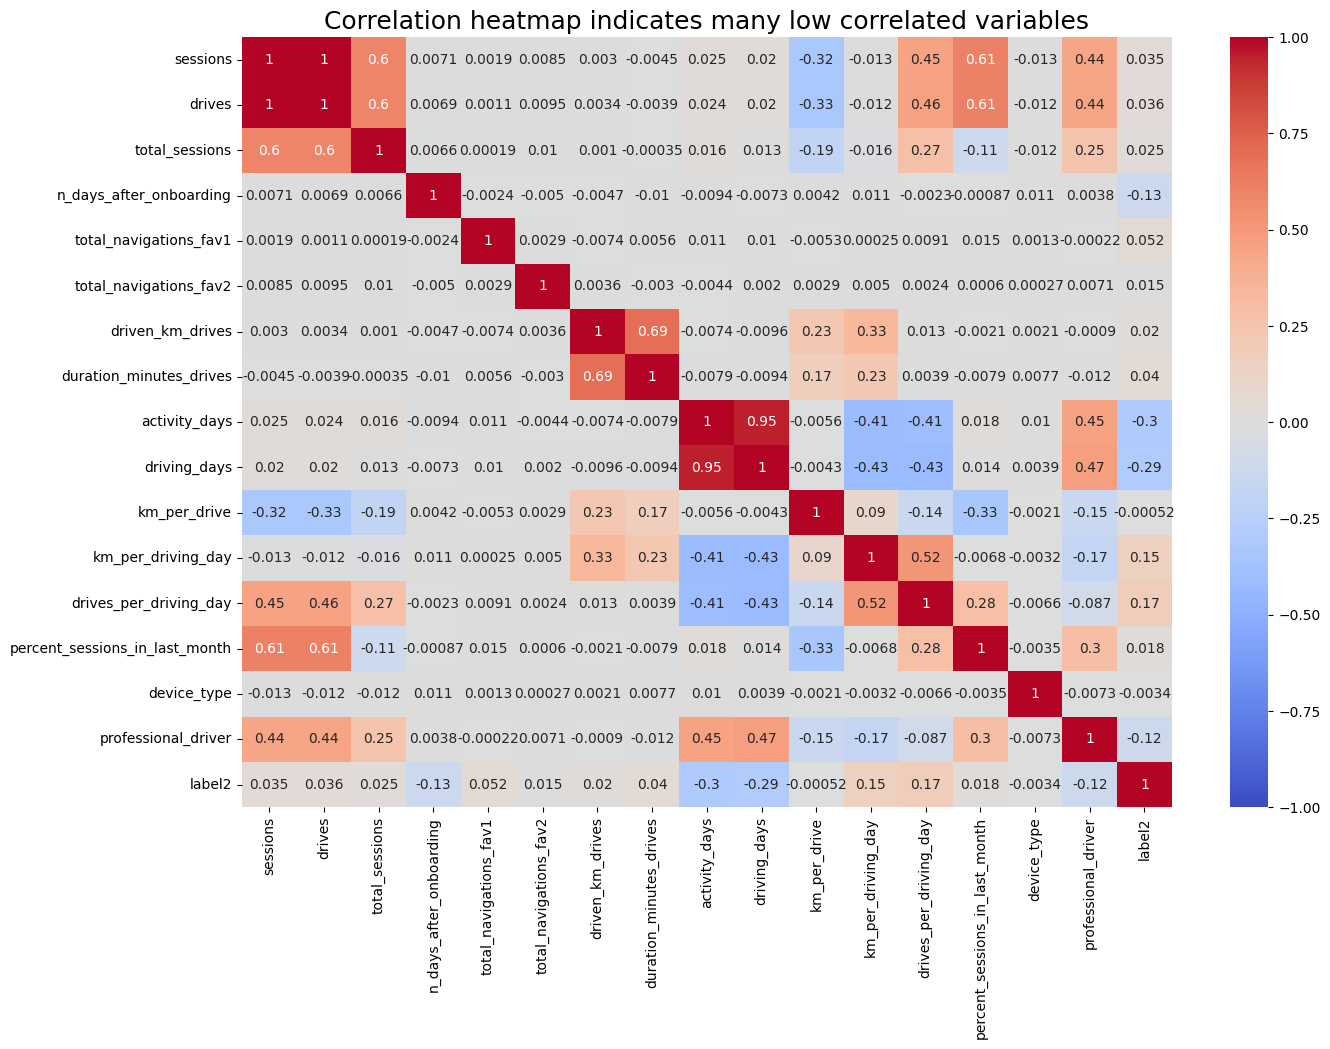

In [0]:
# Plot correlation heatmap
plt.figure(figsize=(15,10))
sns.heatmap(df_numeric.corr(method='pearson'), vmin=-1, vmax=1, annot=True, cmap='coolwarm')
plt.title('Correlation heatmap indicates many low correlated variables', fontsize=18)
plt.show();

If there are predictor variables that have a Pearson correlation coefficient value greater than the absolute value of 0.7, these variables are strongly multicollinear. Therefore, only one of these variables should be used in our model.

Note: 0.7 is an arbitrary threshold. Some industries may use 0.6, 0.8, etc.

Question: Which variables are multicollinear with each other?

• sessions and drives: 1.0

• driving_days and activity_days: 0.95

**Create dummies (if necessary)**

If we select device as an X variable, we will need to create dummy variables since this variable is categorical.

In cases with many categorical variables, we can use pandas built-in pd.get_dummies(), or we can use scikit-learn’s OneHotEncoder() function.

Note: Variables with many categories should only be dummied if absolutely necessary. Each category will result in a coefficient for our model which can lead to overfitting.

Because this dataset only has one remaining categorical feature (device), it’s not necessary to use one of these special functions. We can just implement the transformation directly.

Create a new, binary column called device2 that encodes user devices as follows:
    
• Android -> 0

• iPhone -> 1

In [0]:
# Create new `device2` variable
df['device2'] = np.where(df['device']=='Android', 0, 1)
df[['device', 'device2']].tail()

,device,device2
14994,iPhone,1
14995,Android,0
14996,iPhone,1
14997,iPhone,1
14998,iPhone,1


**Model building**

Assign predictor variables and target 

To build our model we need to determine what X variables we want to include in our model to predict our target—label2.

Drop the following variables and assign the results to X:

• label (this is the target)

• label2 (this is the target)

• device (this is the non-binary-encoded categorical variable)

• sessions (this had high multicollinearity)

• driving_days (this had high multicollinearity)

Note: Notice that sessions and driving_days were selected to be dropped, rather than drives and activity_days. The reason for this is that the features that were kept for modeling had slightly stronger correlations with the target variable than the features that were dropped.

In [0]:
# Isolate predictor variables
X = df.drop(columns = ['label', 'label2', 'device', 'sessions', 'driving_days'])

Now, isolate the dependent (target) variable. Assign it to a variable called y.

In [0]:
# Isolate target variable
y = df['label2']

Split the data 

Use scikit-learn’s train_test_split() function to perform a train/test split on our data using the X and y variables we assigned above.

Note 1: It is important to do a train test to obtain accurate predictions. We always want to fit our model on our training set and evaluate our model on our test set to avoid data leakage.

Note 2: Because the target class is imbalanced (82% retained vs. 18% churned), we want to make sure that we don’t get an unlucky split that over- or under-represents the frequency of the minority class. Set the function’s stratify parameter to y to ensure that the minority class appears in both train and test sets in the same proportion that it does in the overall dataset.

In [0]:
# Perform the train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)

In [0]:
# Use .head()
X_train.head()

,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,km_per_drive,km_per_driving_day,drives_per_driving_day,percent_sessions_in_last_month,device_type,professional_driver,device2
152,108,186.192746,3116,243,124,8889.794236,4668.180092,24,85.042481,592.652949,7.200000,0.698201,1,1,1
11899,2,3.487590,794,114,18,3286.545691,1780.902733,5,1643.272845,3286.545691,2.000000,0.573462,1,0,1
10937,139,347.106403,331,4,7,7400.838975,2349.305267,15,53.243446,616.736581,11.583333,0.492644,2,0,0
669,108,454.363204,2320,11,4,6566.424830,4558.459870,18,60.800230,410.401552,6.750000,0.272322,1,1,1
8406,10,89.475821,2478,135,0,1271.248661,938.711572,27,127.124866,74.779333,0.588235,0.111762,1,0,1


Use scikit-learn to instantiate a logistic regression model. Add the argument penalty = None.

It is important to add penalty = 'none' since our predictors are unscaled.

Fit the model on X_train and y_train.

In [0]:
import pandas as pd

X_train.isna().sum()

drives                            0
total_sessions                    0
n_days_after_onboarding           0
total_navigations_fav1            0
total_navigations_fav2            0
driven_km_drives                  0
duration_minutes_drives           0
activity_days                     0
km_per_drive                      0
km_per_driving_day                0
drives_per_driving_day            7
percent_sessions_in_last_month    0
device_type                       0
professional_driver               0
device2                           0
dtype: int64

In [0]:

np.isinf(X_train).sum().sort_values(ascending=False)

drives_per_driving_day            754
km_per_drive                       82
drives                              0
total_sessions                      0
n_days_after_onboarding             0
total_navigations_fav1              0
total_navigations_fav2              0
driven_km_drives                    0
duration_minutes_drives             0
activity_days                       0
km_per_driving_day                  0
percent_sessions_in_last_month      0
device_type                         0
professional_driver                 0
device2                             0
dtype: int64

In [0]:
for df in [X_train, X_test]:
    # Avoid division by zero safely
    df['drives_per_driving_day'] = np.where(
        df['activity_days'] == 0,
        0,
        df['drives'] / df['activity_days']
    )

    df['km_per_drive'] = np.where(
        df['drives'] == 0,
        0,
        df['driven_km_drives'] / df['drives']
    )

In [0]:
model = LogisticRegression(penalty=None, max_iter=400)
model.fit(X_train, y_train)

/databricks/python/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=400, penalty=None)

Call the .coef_ attribute on the model to get the coefficients of each variable. The coefficients are in order of how the variables are listed in the dataset. Remember that the coefficients represent the change in the log odds of the target variable for every one unit increase in X.

In [0]:
pd.Series(model.coef_[0], index=X.columns)

drives                            0.002251
total_sessions                    0.000301
n_days_after_onboarding          -0.000410
total_navigations_fav1            0.001221
total_navigations_fav2            0.000884
driven_km_drives                 -0.000021
duration_minutes_drives           0.000108
activity_days                    -0.106232
km_per_drive                      0.000119
km_per_driving_day                0.000012
drives_per_driving_day            0.000372
percent_sessions_in_last_month   -0.000914
device_type                      -0.002931
professional_driver              -0.001379
device2                          -0.001250
dtype: float64

Call the model’s intercept_ attribute to get the intercept of the model.

In [0]:
model.intercept_

array([-0.00209065])

Check final assumption Verify the linear relationship between X and the estimated log odds (known as logits) by making a regplot.

Call the model’s predict_proba() method to generate the probability of response for each sample in the training data. (The training data is the argument to the method.) Assign the result to a variable called training_probabilities. This results in a 2-D array where each row represents a user in X_train. The first column is the probability of the user not churning, and the second column is the probability of the user churning.

In [0]:
# Get the predicted probabilities of the training data
training_probabilities = model.predict_proba(X_train)
training_probabilities

array([[0.94234699, 0.05765301],
       [0.58501795, 0.41498205],
       [0.76723154, 0.23276846],
       ...,
       [0.92144154, 0.07855846],
       [0.85023153, 0.14976847],
       [0.93549414, 0.06450586]])

In logistic regression, the relationship between a predictor variable and the dependent variable does not need to be linear, however, the log-odds (a.k.a., logit) of the dependent variable with respect to the predictor variable should be linear. Here is the formula for calculating log-odds, where p is the probability of response:

      logit(p) = ln(p/1 - p)

1. Create a dataframe called logit_data that is a copy of df.

2. Create a new column called logit in the logit_data dataframe. The data in this column should represent the logit for each user.

In [0]:
# 1. Copy the `X_train` dataframe and assign to `logit_data`
logit_data = X_train.copy()

# 2. Create a new `logit` column in the `logit_data` df
logit_data['logit'] = [np.log(prob[1] / prob[0]) for prob in training_probabilities]

Plot a regplot where the x-axis represents an independent variable and the y-axis represents the log-odds of the predicted probabilities.

In an exhaustive analysis, this would be plotted for each continuous or discrete predictor variable.

Here we show only activity_days.

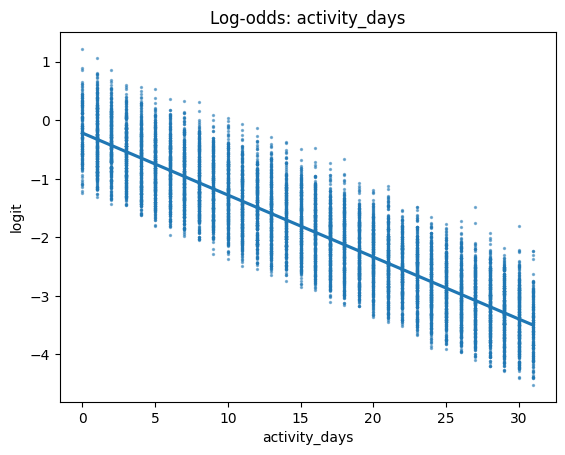

In [0]:
# Plot regplot of `activity_days` log-odds
sns.regplot(x='activity_days', y='logit', data=logit_data, scatter_kws={'s': 2, 'alpha': 0.5})
plt.title('Log-odds: activity_days');

Results and evaluation

If the logistic assumptions are met, the model results can be appropriately interpreted.

Use the code block below to make predictions on the test data.

In [0]:
# Generate predictions on X_test
y_preds = model.predict(X_test)

Now, use the score() method on the model with X_test and y_test as its two arguments. The default score in scikit-learn is accuracy. What is the accuracy of our model?

Consider: Is accuracy the best metric to use to evaluate this model?

In [0]:
# Score the model (accuracy) on the test data
model.score(X_test, y_test)

0.8237762237762237

**Show results with a confusion matrix**

Use the confusion_matrix function to obtain a confusion matrix. Use y_test and y_preds as arguments.

In [0]:
cm = confusion_matrix(y_test, y_preds)

Next, use the ConfusionMatrixDisplay() function to display the confusion matrix from the above cell, passing the confusion matrix we just created as its argument.

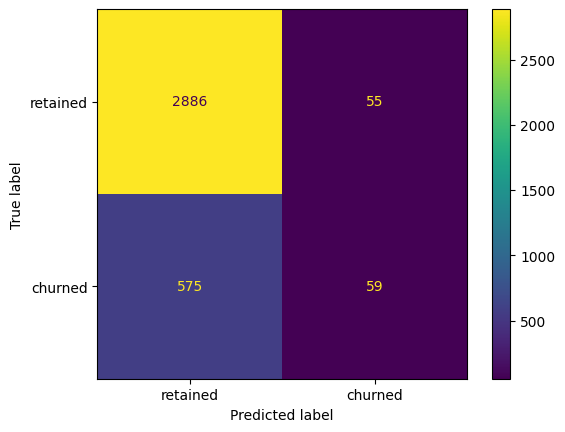

In [0]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                            display_labels=['retained', 'churned'],
                            )
disp.plot();

We can use the confusion matrix to compute precision and recall manually. We can also use scikit-learn’s classification_report() function to generate a table from y_test and y_preds.

In [0]:
# Calculate precision manually
precision = cm[1,1] / (cm[0, 1] + cm[1, 1])
precision

np.float64(0.5175438596491229)

In [0]:
# Calculate recall manually
recall = cm[1,1] / (cm[1, 0] + cm[1, 1])
recall

np.float64(0.09305993690851735)

In [0]:
# Create a classification report
target_labels = ['retained', 'churned']
print(classification_report(y_test, y_preds, target_names=target_labels))

              precision    recall  f1-score   support

    retained       0.83      0.98      0.90      2941
     churned       0.52      0.09      0.16       634

    accuracy                           0.82      3575
   macro avg       0.68      0.54      0.53      3575
weighted avg       0.78      0.82      0.77      3575



Note: The model has mediocre precision and very low recall, which means that it makes a lot of false negative predictions and fails to capture users who will churn.

Generate a bar graph of the model’s coefficients for a visual representation of the importance of the model’s features.

In [0]:
# Create a list of (column_name, coefficient) tuples
feature_importance = list(zip(X_train.columns, model.coef_[0]))

# Sort the list by coefficient value
feature_importance = sorted(feature_importance, key=lambda x: x[1], reverse=True)
feature_importance

[('drives', np.float64(0.002250851255660068)),
 ('total_navigations_fav1', np.float64(0.0012207615198573554)),
 ('total_navigations_fav2', np.float64(0.0008840434812474249)),
 ('drives_per_driving_day', np.float64(0.0003718807301546661)),
 ('total_sessions', np.float64(0.00030122068186446045)),
 ('km_per_drive', np.float64(0.00011913532801701576)),
 ('duration_minutes_drives', np.float64(0.00010798693266474462)),
 ('km_per_driving_day', np.float64(1.2214551285969474e-05)),
 ('driven_km_drives', np.float64(-2.0882481288050816e-05)),
 ('n_days_after_onboarding', np.float64(-0.00041036851087343485)),
 ('percent_sessions_in_last_month', np.float64(-0.0009135051000566293)),
 ('device2', np.float64(-0.001250329916046445)),
 ('professional_driver', np.float64(-0.0013786519273448056)),
 ('device_type', np.float64(-0.002930970524613685)),
 ('activity_days', np.float64(-0.10623159460874657))]

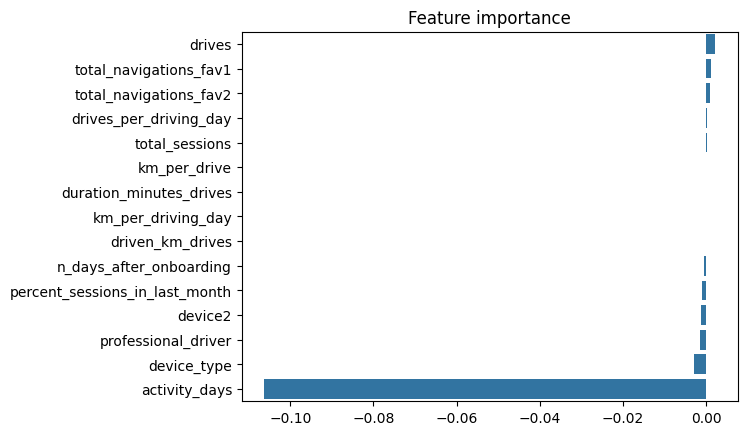

In [0]:
# Plot the feature importances
import seaborn as sns
sns.barplot(x=[x[1] for x in feature_importance],
            y=[x[0] for x in feature_importance],
            orient='h')
plt.title('Feature importance');

**Build a machine learning model**

In [0]:
%pip install xgboost

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
# Import packages for data manipulation
import numpy as np
import pandas as pd

# Import packages for data visualization
import matplotlib.pyplot as plt

# This lets us see all of the columns, preventing Juptyer from redacting them.
pd.set_option('display.max_columns', None)

# Import packages for data modeling
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import roc_auc_score, roc_curve, auc
from sklearn.metrics import accuracy_score, precision_score, recall_score,\
f1_score, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# This is the function that helps plot feature importance
from xgboost import plot_importance

# This module lets us save our models once we fit them.
import pickle

Now read in the dataset as df0 and inspect the first five rows.

In [0]:
# Import dataset
df0 = spark.table("waze.default.waze_dataset").toPandas()

In [0]:
# Inspect the first five rows
df0.head()

,ID,label,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days,device
0,0,retained,283,226,296.748273,2276,208,0,2628.845068,1985.775061,28,19,Android
1,1,retained,133,107,326.896596,1225,19,64,13715.920550,3160.472914,13,11,iPhone
2,2,retained,114,95,135.522926,2651,0,0,3059.148818,1610.735904,14,8,Android
3,3,retained,49,40,67.589221,15,322,7,913.591123,587.196542,7,3,iPhone
4,4,retained,84,68,168.247020,1562,166,5,3950.202008,1219.555924,27,18,Android


**Feature engineering**

We have already prepared much of this data and performed exploratory data analysis (EDA). We know that some features had stronger correlations with churn than others, and we also created some features that may be useful. In this part of the project, we'll engineer these features and some new features to use for modeling.

To begin, create a copy of df0 to preserve the original dataframe. Call the copy df.

In [0]:
# Copy the df0 dataframe
df = df0.copy()

Call info() on the new dataframe so the existing columns can be easily referenced.

In [0]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       14999 non-null  int64  
 1   label                    14299 non-null  object 
 2   sessions                 14999 non-null  int64  
 3   drives                   14999 non-null  int64  
 4   total_sessions           14999 non-null  float64
 5   n_days_after_onboarding  14999 non-null  int64  
 6   total_navigations_fav1   14999 non-null  int64  
 7   total_navigations_fav2   14999 non-null  int64  
 8   driven_km_drives         14999 non-null  float64
 9   duration_minutes_drives  14999 non-null  float64
 10  activity_days            14999 non-null  int64  
 11  driving_days             14999 non-null  int64  
 12  device                   14999 non-null  object 
dtypes: float64(3), int64(8), object(2)
memory usage: 1.5+ MB


km_per_driving_day

1.	Create a feature representing the mean number of kilometers driven on each driving day in the last month for each user. Add this feature as a column to df.

2.	Get descriptive statistics for this new feature


In [0]:
# 1. Create `km_per_driving_day` feature
df['km_per_driving_day'] = df['driven_km_drives'] / df['driving_days']

# 2. Get descriptive stats
df['km_per_driving_day'].describe()

/databricks/python/lib/python3.12/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


count    1.499900e+04
mean              inf
std               NaN
min      3.022063e+00
25%      1.672804e+02
50%      3.231459e+02
75%      7.579257e+02
max               inf
Name: km_per_driving_day, dtype: float64

In [0]:
# 1. Convert infinite values to zero
df.loc[df['km_per_driving_day']==np.inf, 'km_per_driving_day'] = 0

# 2. Confirm that it worked
df['km_per_driving_day'].describe()

count    14999.000000
mean       578.963113
std       1030.094384
min          0.000000
25%        136.238895
50%        272.889272
75%        558.686918
max      15420.234110
Name: km_per_driving_day, dtype: float64

**percent_sessions_in_last_month**

1.	Create a new column percent_sessions_in_last_month that represents the percentage of each user's total sessions that were logged in their last month of use.

2.	Get descriptive statistics for this new feature


In [0]:
# 1. Create `percent_sessions_in_last_month` feature
df['percent_sessions_in_last_month'] = df['sessions'] / df['total_sessions']

# 2. Get descriptive stats
df['percent_sessions_in_last_month'].describe()

count    14999.000000
mean         0.449255
std          0.286919
min          0.000000
25%          0.196221
50%          0.423097
75%          0.687216
max          1.530637
Name: percent_sessions_in_last_month, dtype: float64

**professional_driver**

Create a new, binary feature called professional_driver that is a 1 for users who had 60 or more drives and drove on 15+ days in the last month.

Note: The objective is to create a new feature that separates professional drivers from other drivers. In this scenario, domain knowledge and intuition are used to determine these deciding thresholds, but ultimately they are arbitrary.

To create this column, use the np.where() function. This function accepts as arguments:

1.	A condition

2.	What to return when the condition is true

3.	What to return when the condition is false

Example:

x = [1, 2, 3]

x = np.where(x > 2, 100, 0)

x

array([  0,   0, 100])


In [0]:
# Create `professional_driver` feature
df['professional_driver'] = np.where((df['drives'] >= 60) & (df['driving_days'] >= 15), 1, 0)

**total_sessions_per_day**

Now, create a new column that represents the mean number of sessions per day since onboarding.

In [0]:
# Create `total_sessions_per_day` feature
df['total_sessions_per_day'] = df['total_sessions'] / df['n_days_after_onboarding']

As with other features, get descriptive statistics for this new feature.

In [0]:
# Get descriptive stats
df['total_sessions_per_day'].describe()

count    14999.000000
mean         0.338698
std          1.314333
min          0.000298
25%          0.051037
50%          0.100775
75%          0.216269
max         39.763874
Name: total_sessions_per_day, dtype: float64

**km_per_hour**

Create a column representing the mean kilometers per hour driven in the last month.


In [0]:
# Create `km_per_hour` feature
df['km_per_hour'] = df['driven_km_drives'] / (df['duration_minutes_drives'] / 60)
df['km_per_hour'].describe()

count    14999.000000
mean       190.394608
std        334.674026
min         72.013095
25%         90.706222
50%        122.382022
75%        193.130119
max      23642.920871
Name: km_per_hour, dtype: float64

These numbers are obviously problematic, and it would be worthwhile to seek clarification from Waze regarding how these features are collected to better understand why such unrealistic speeds are observed.

**km_per_drive**

Create a column representing the mean number of kilometers per drive made in the last month for each user. Then, print descriptive statistics for the feature.

In [0]:
# Create `km_per_drive` feature
df['km_per_drive'] = df['driven_km_drives'] / df['drives']
df['km_per_drive'].describe()

/databricks/python/lib/python3.12/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


count    1.499900e+04
mean              inf
std               NaN
min      1.008775e+00
25%      3.323065e+01
50%      7.488006e+01
75%      1.854667e+02
max               inf
Name: km_per_drive, dtype: float64

This feature has infinite values too. Convert the infinite values to zero, then confirm that it worked.

In [0]:
# 1. Convert infinite values to zero
df.loc[df['km_per_drive']==np.inf, 'km_per_drive'] = 0

# 2. Confirm that it worked
df['km_per_drive'].describe()

count    14999.000000
mean       232.817946
std        620.622351
min          0.000000
25%         32.424301
50%         72.854343
75%        179.347527
max      15777.426560
Name: km_per_drive, dtype: float64

**percent_of_sessions_to_favorite**

Finally, create a new column that represents the percentage of total sessions that were used to navigate to one of the users' favorite places. Then, print descriptive statistics for the new column.

This is a proxy representation for the percent of overall drives that are to a favorite place. Since total drives since onboarding are not contained in this dataset, total sessions must serve as a reasonable approximation.

People whose drives to non-favorite places make up a higher percentage of their total drives might be less likely to churn, since they're making more drives to less familiar places.


In [0]:
# Create `percent_of_sessions_to_favorite` feature
df['percent_of_drives_to_favorite'] = (
    df['total_navigations_fav1'] + df['total_navigations_fav2']) / df['total_sessions']

# Get descriptive stats
df['percent_of_drives_to_favorite'].describe()

count    14999.000000
mean         1.665439
std          8.865666
min          0.000000
25%          0.203471
50%          0.649818
75%          1.638526
max        777.563629
Name: percent_of_drives_to_favorite, dtype: float64

**Drop missing values**

Because we know from previous EDA that there is no evidence of a non-random cause of the 700 missing values in the label column, and because these observations comprise less than 5% of the data, use the dropna() method to drop the rows that are missing this data.

In [0]:
# Drop rows with missing values
df = df.dropna(subset=['label'])

**Outliers**

We know from previous EDA that many of these columns have outliers. However, tree-based models are resilient to outliers, so there is no need to make any imputations.

**Variable encoding**

**Dummying features**

In order to use device as an X variable, we will need to convert it to binary, since this variable is categorical.

In cases where the data contains many categorical variables, we can use pandas built-in pd.get_dummies(), or we can use scikit-learn's OneHotEncoder() function.

Note: Each possible category of each feature will result in a feature for our model, which could lead to an inadequate ratio of features to observations and/or difficulty understanding our model's predictions.

Because this dataset only has one remaining categorical feature (device), it's not necessary to use one of these special functions. We can just implement the transformation directly.

Create a new, binary column called device2 that encodes user devices as follows:

•	Android -> 0

•	iPhone -> 1

In [0]:
# Create new `device2` variable
df['device2'] = np.where(df['device']=='Android', 0, 1)
df[['device', 'device2']].tail()

,device,device2
14994,iPhone,1
14995,Android,0
14996,iPhone,1
14997,iPhone,1
14998,iPhone,1


**Target encoding**

The target variable is also categorical, since a user is labeled as either "churned" or "retained." Change the data type of the label column to be binary. This change is needed to train the models.

Assign a 0 for all retained users.

Assign a 1 for all churned users.

Save this variable as label2 so as not to overwrite the original label variable.

Note: There are many ways to do this. Consider using np.where()

In [0]:
# Create binary `label2` column
df['label2'] = np.where(df['label']=='churned', 1, 0)
df[['label', 'label2']].tail()

,label,label2
14994,retained,0
14995,retained,0
14996,retained,0
14997,churned,1
14998,retained,0


**Feature selection**

Tree-based models can handle multicollinearity, so the only feature that can be cut is ID, since it doesn't contain any information relevant to churn.

Note, however, that device won't be used simply because it's a copy of device2.

Drop ID from the df dataframe.

In [0]:
# Drop `ID` column
df = df.drop(['ID'], axis=1)

**Evaluation metric**

Before modeling, we must decide on an evaluation metric. This will depend on the class balance of the target variable and the use case of the model.

First, examine the class balance of your target variable.

In [0]:
# Get class balance of 'label' col
df['label'].value_counts(normalize=True)

label
retained    0.822645
churned     0.177355
Name: proportion, dtype: float64

Approximately 18% of the users in this dataset churned. This is an unbalanced dataset, but not extremely so. It can be modeled without any class rebalancing.

Now, consider which evaluation metric is best. Accuracy might not be the best gauge of performance because a model can have high accuracy on an imbalanced dataset and still fail to predict the minority class.

It was already determined that the risks involved in making a false positive prediction are minimal. No one stands to get hurt, lose money, or suffer any other significant consequence if they are predicted to churn. Therefore, select the model based on the recall score.

**Modeling workflow and model selection process**

The final modeling dataset contains 14,299 samples. This is towards the lower end of what might be considered sufficient to conduct a robust model selection process, but still doable.

1.	Split the data into train/validation/test sets (60/20/20)

Note that, when deciding the split ratio and whether or not to use a validation set to select a champion model, consider both how many samples will be in each data partition, and how many examples of the minority class each would therefore contain. In this case, a 60/20/20 split would result in ~2,860 samples in the validation set and the same number in the test set, of which ~18% - or 515 samples—would represent users who churn.

2.	Fit models and tune hyperparameters on the training set

3.	Perform final model selection on the validation set

4.	Assess the champion model's performance on the test set

**Split the data**

Now we're ready to model. The only remaining step is to split the data into features/target variable and training/validation/test sets.

1.	Define a variable X that isolates the features. Remember not to use device.

2.	Define a variable y that isolates the target variable (label2).

3.	Split the data 80/20 into an interim training set and a test set. Don't forget to stratify the splits, and set the random state to 42.

4.	Split the interim training set 75/25 into a training set and a validation set, yielding a final ratio of 60/20/20 for training/validation/test sets. Again, don't forget to stratify the splits and set the random state.

In [0]:
# 1. Isolate X variables
X = df.drop(columns=['label', 'label2', 'device'])

# 2. Isolate y variable
y = df['label2']

# 3. Split into train and test sets
X_tr, X_test, y_tr, y_test = train_test_split(X, y, stratify=y,
                                              test_size=0.2, random_state=42)

# 4. Split into train and validate sets
X_train, X_val, y_train, y_val = train_test_split(X_tr, y_tr, stratify=y_tr,
                                                  test_size=0.25, random_state=42)

In [0]:
# Verify the number of samples in the partitioned data
for x in [X_train, X_val, X_test]:
    print(len(x))

8579
2860
2860


This aligns with expectations.

**Modeling**

**Random forest**

Begin with using GridSearchCV to tune a random forest model.

1.	Instantiate the random forest classifier rf and set the random state.

2.	Create a dictionary cv_params of any of the following hyperparameters and their corresponding values to tune. The more we tune, the better our model will fit the data, but the longer it will take.

•	max_depth

•	max_features

•	max_samples

•	min_samples_leaf

•	min_samples_split

•	n_estimators

3.	Define a list scoring of scoring metrics for GridSearch to capture (precision, recall, F1 score, and accuracy).

4.	Instantiate the GridSearchCV object rf_cv. Pass to it as arguments:

•	estimator=rf

•	param_grid=cv_params

•	scoring=scoring

•	cv: define the number of cross-validation folds you want (cv=_)

•	refit: indicate which evaluation metric we want to use to select the model (refit=_)

refit should be set to 'recall'.

Note: To save time, this project doesn't use multiple values for each parameter in the grid search, but we should include a range of values in our search to home in on the best set of parameters.

In [0]:
# 1. Instantiate the random forest classifier
rf = RandomForestClassifier(random_state=42)

# 2. Create a dictionary of hyperparameters to tune
cv_params = {'max_depth': [None],
             'max_features': [1.0],
             'max_samples': [1.0],
             'min_samples_leaf': [2],
             'min_samples_split': [2],
             'n_estimators': [300],
             }

# 3. Define a list of scoring metrics to capture
scoring = ['accuracy', 'precision', 'recall', 'f1']

# 4. Instantiate the GridSearchCV object
rf_cv = GridSearchCV(rf, cv_params, scoring=scoring, cv=4, refit='recall')

In [0]:
# Now fit the model to the training data
rf_cv.fit(X_train, y_train)

GridSearchCV(cv=4, estimator=RandomForestClassifier(random_state=42),
             param_grid={'max_depth': [None], 'max_features': [1.0],
                         'max_samples': [1.0], 'min_samples_leaf': [2],
                         'min_samples_split': [2], 'n_estimators': [300]},
             refit='recall', scoring=['accuracy', 'precision', 'recall', 'f1'])

Examine the best average score across all the validation folds.

In [0]:
# Examine best score
rf_cv.best_score_

np.float64(0.12678201409034398)

Examine the best combination of hyperparameters.

In [0]:
# Examine best hyperparameter combo
rf_cv.best_params_

{'max_depth': None,
 'max_features': 1.0,
 'max_samples': 1.0,
 'min_samples_leaf': 2,
 'min_samples_split': 2,
 'n_estimators': 300}

Use the make_results() function to output all of the scores of your model. Note that the function accepts three arguments.

In [0]:
def make_results(model_name:str, model_object, metric:str):
    '''
    Arguments:
        model_name (string): what we want the model to be called in the output table
        model_object: a fit GridSearchCV object
        metric (string): precision, recall, f1, or accuracy

    Returns a pandas df with the F1, recall, precision, and accuracy scores
    for the model with the best mean 'metric' score across all validation folds.
    '''

    # Create dictionary that maps input metric to actual metric name in GridSearchCV
    metric_dict = {'precision': 'mean_test_precision',
                   'recall': 'mean_test_recall',
                   'f1': 'mean_test_f1',
                   'accuracy': 'mean_test_accuracy',
                   }

    # Get all the results from the CV and put them in a df
    cv_results = pd.DataFrame(model_object.cv_results_)

    # Isolate the row of the df with the max(metric) score
    best_estimator_results = cv_results.iloc[cv_results[metric_dict[metric]].idxmax(), :]

    # Extract accuracy, precision, recall, and f1 score from that row
    f1 = best_estimator_results.mean_test_f1
    recall = best_estimator_results.mean_test_recall
    precision = best_estimator_results.mean_test_precision
    accuracy = best_estimator_results.mean_test_accuracy

    # Create table of results
    table = pd.DataFrame({'model': [model_name],
                          'precision': [precision],
                          'recall': [recall],
                          'F1': [f1],
                          'accuracy': [accuracy],
                          },
                         )

    return table

In [0]:
# Pass the GridSearch object to the make_results() function
results = make_results('RF cv', rf_cv, 'recall')
results

,model,precision,recall,F1,accuracy
0,RF cv,0.457163,0.126782,0.198445,0.81851


Asside from the accuracy, the scores aren't that good. However, recall that when we built the logistic regression model the recall was ~0.09, which means that this model has 33% better recall and about the same accuracy, and it was trained on less data.

**XGBoost**

Try to improve our scores using an XGBoost model.

1.	Instantiate the XGBoost classifier xgb and set objective='binary:logistic'. Also set the random state.

2.	Create a dictionary cv_params of the following hyperparameters and their corresponding values to tune:

•	max_depth

•	min_child_weight

•	learning_rate

•	n_estimators

3.	Define a list scoring of scoring metrics for grid search to capture (precision, recall, F1 score, and accuracy).

4.	Instantiate the GridSearchCV object xgb_cv. Pass to it as arguments:

•	estimator=xgb

•	param_grid=cv_params

•	scoring=scoring

•	cv: define the number of cross-validation folds you want (cv=_)

•	refit: indicate which evaluation metric you want to use to select the model (refit='recall')

In [0]:
# 1. Instantiate the XGBoost classifier
xgb = XGBClassifier(objective='binary:logistic', random_state=42)

# 2. Create a dictionary of hyperparameters to tune
cv_params = {'max_depth': [6, 12],
             'min_child_weight': [3, 5],
             'learning_rate': [0.01, 0.1],
             'n_estimators': [300]
             }

# 3. Define a list of scoring metrics to capture
scoring = ['accuracy', 'precision', 'recall', 'f1']

# 4. Instantiate the GridSearchCV object
xgb_cv = GridSearchCV(xgb, cv_params, scoring=scoring, cv=4, refit='recall')

In [0]:
# Now fit the model to the X_train and y_train data
xgb_cv.fit(X_train, y_train)

GridSearchCV(cv=4,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, feature_weights=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=Non...
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             param_grid={'learning_rate': [0.01, 0.1], 'max_depth': [6, 12],
                         'min_child_weight': [3, 5], 'n_estimators': [300]},
             refit='recall', scoring=['accuracy', 'precision', 'recall', 'f1'])

Get the best score and best parameters from this model.

In [0]:
# Examine best score
xgb_cv.best_score_

np.float64(0.17936351706036746)

In [0]:
# Examine best parameters
xgb_cv.best_params_

{'learning_rate': 0.1,
 'max_depth': 12,
 'min_child_weight': 5,
 'n_estimators': 300}

Use the make_results() function to output all of the scores of our model. Note that the function accepts three arguments.

In [0]:
# Call 'make_results()' on the GridSearch object
xgb_cv_results = make_results('XGB cv', xgb_cv, 'recall')
results = pd.concat([results, xgb_cv_results], axis=0)
results

,model,precision,recall,F1,accuracy
0,RF cv,0.457163,0.126782,0.198445,0.818510
0,XGB cv,0.424500,0.179364,0.251974,0.811167


This model fit the data even better than the random forest model. The recall score is nearly double the recall score from the logistic regression model, and it's almost 50% better than the random forest model's recall score, while maintaining a similar accuracy and precision score.

**Model selection**

Now, use the best random forest model and the best XGBoost model to predict on the validation data. Whichever performs better will be selected as the champion model.

**Random forest**

In [0]:
# Use random forest model to predict on validation data
rf_val_preds = rf_cv.best_estimator_.predict(X_val)

Use the get_test_scores() function to generate a table of scores from the predictions on the validation data.

In [0]:
def get_test_scores(model_name:str, preds, y_test_data):
    '''
    Generate a table of test scores.

    In:
        model_name (string): Our choice: how the model will be named in the output table
        preds: numpy array of test predictions
        y_test_data: numpy array of y_test data

    Out:
        table: a pandas df of precision, recall, f1, and accuracy scores for your model
    '''
    accuracy = accuracy_score(y_test_data, preds)
    precision = precision_score(y_test_data, preds)
    recall = recall_score(y_test_data, preds)
    f1 = f1_score(y_test_data, preds)

    table = pd.DataFrame({'model': [model_name],
                          'precision': [precision],
                          'recall': [recall],
                          'F1': [f1],
                          'accuracy': [accuracy]
                          })

    return table

In [0]:
# Get validation scores for RF model
rf_val_scores = get_test_scores('RF val', rf_val_preds, y_val)

# Append to the results table
results = pd.concat([results, rf_val_scores], axis=0)
results

,model,precision,recall,F1,accuracy
0,RF cv,0.457163,0.126782,0.198445,0.818510
0,XGB cv,0.424500,0.179364,0.251974,0.811167
0,RF val,0.445255,0.120316,0.189441,0.817483


Notice that the scores went down from the training scores across all metrics, but only by very little. This means that the model did not overfit the training data.

**XGBoost**

Now, do the same thing to get the performance scores of the XGBoost model on the validation data.

In [0]:
# Use XGBoost model to predict on validation data
xgb_val_preds = xgb_cv.best_estimator_.predict(X_val)

# Get validation scores for XGBoost model
xgb_val_scores = get_test_scores('XGB val', xgb_val_preds, y_val)

# Append to the results table
results = pd.concat([results, xgb_val_scores], axis=0)
results

,model,precision,recall,F1,accuracy
0,RF cv,0.457163,0.126782,0.198445,0.818510
0,XGB cv,0.424500,0.179364,0.251974,0.811167
0,RF val,0.445255,0.120316,0.189441,0.817483
0,XGB val,0.395556,0.175542,0.243169,0.806294


Just like with the random forest model, the XGBoost model's validation scores were lower, but only very slightly. It is still the clear champion.

**Use champion model to predict on test data**

Now, use the champion model to predict on the test dataset. This is to give a final indication of how we should expect the model to perform on new future data, should we decide to use the model.

In [0]:
# Use XGBoost model to predict on test data
xgb_test_preds = xgb_cv.best_estimator_.predict(X_test)

# Get test scores for XGBoost model
xgb_test_scores = get_test_scores('XGB test', xgb_test_preds, y_test)

# Append to the results table
results = pd.concat([results, xgb_test_scores], axis=0)
results

,model,precision,recall,F1,accuracy
0,RF cv,0.457163,0.126782,0.198445,0.818510
0,XGB cv,0.424500,0.179364,0.251974,0.811167
0,RF val,0.445255,0.120316,0.189441,0.817483
0,XGB val,0.395556,0.175542,0.243169,0.806294
0,XGB test,0.416327,0.201183,0.271277,0.808392


The recall was exactly the same as it was on the validation data, but the precision declined notably, which caused all of the other scores to drop slightly. Nonetheless, this is stil within the acceptable range for performance discrepancy between validation and test scores.

**Confusion matrix**

Plot a confusion matrix of the champion model's predictions on the test data.

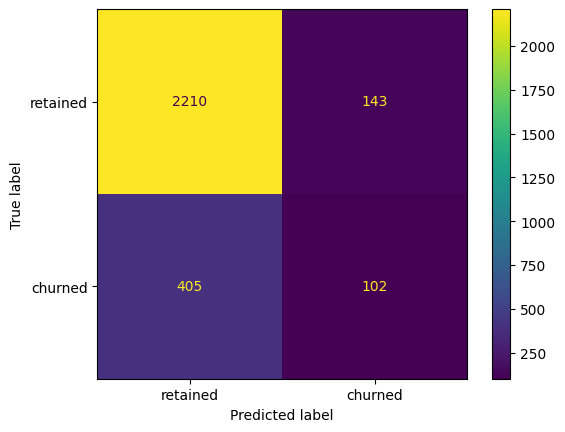

In [0]:
# Generate array of values for confusion matrix
cm = confusion_matrix(y_test, xgb_test_preds, labels=xgb_cv.classes_)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                             display_labels=['retained', 'churned'])
disp.plot();

The model predicted almost three times as many false negatives than it did false positives, and it correctly identified only 20.1% (102/[102+405]) of the users who actually churned.

**Feature importance**

Use the plot_importance function to inspect the most important features of your final model.

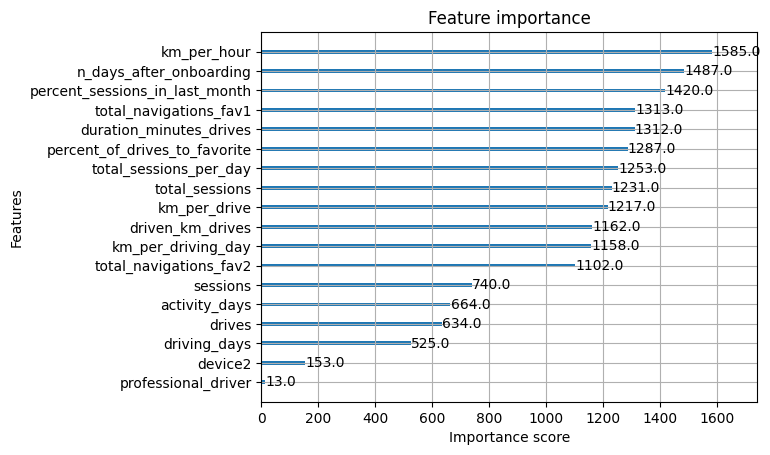

In [0]:
plot_importance(xgb_cv.best_estimator_);

The XGBoost model made more use of many of the features than did the logistic regression model, which weighted a single feature (activity_days) very heavily in its final prediction.

If anything, this underscores the importance of feature engineering. Notice that engineered features accounted for six of the top 10 features (and three of the top five). Feature engineering is often one of the best and easiest ways to boost model performance.